# Deep Learning - Clasificación de Lesiones Cutáneas

**Autores:** David Moreda Amezcua, Javier Cerón Contreras, Pedro Martínez Huertas

**Máster en Inteligencia Artificial - Universidad Loyola**

## 1. Preparación de Datos y Prevención de Data Leakage

### Estructura del Proyecto

El proyecto se organiza en tres bloques:
- **Bloque A**: Deep Learning (solo imágenes)
- **Bloque B**: Machine Learning (solo datos tabulares)
- **Bloque C**: Modelos Híbridos (imágenes + tabulares)

### Split Train/Test

Para que los resultados sean comparables entre bloques, usamos el mismo split de datos:
- Train y test definidos por `Train_clean.csv` y `Test_clean.csv`
- Todos los bloques ven exactamente las mismas imágenes
- El test se mantiene completamente separado hasta la evaluación final

### Las 6 Clases

| Clase | Descripción |
|-------|-------------|
| ACK | Queratosis Actínica |
| BCC | Carcinoma Basocelular |
| MEL | Melanoma (crítico) |
| NEV | Nevus (lunar benigno) |
| SCC | Carcinoma de Células Escamosas |
| SEK | Queratosis Seborreica |

In [1]:
import os
import pandas as pd
import shutil

BASE = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos"
IMG_SRC = os.path.join(BASE, "images", "MULTICLASE")
IMG_DST = os.path.join(BASE, "images", "SPLIT_MULTICLASE")

df_train = pd.read_csv(os.path.join(BASE, "Train_clean.csv"))
df_test = pd.read_csv(os.path.join(BASE, "Test_clean.csv"))

class_names = {0: "ACK", 1: "BCC", 2: "MEL", 3: "NEV", 4: "SCC", 5: "SEK"}
binary_names = {0: "Benigno", 1: "Maligno"}
splits = {"train": df_train, "test": df_test}



for split_name in splits:
    for class_name in class_names.values():
        os.makedirs(os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, class_name), exist_ok=True)
    for bin_name in binary_names.values():
        os.makedirs(os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name), exist_ok=True)

for split_name, df in splits.items():
    for _, row in df.iterrows():
        diag = row["diagnostic"]
        diag_bin = row["diagnostic_binario"]
        multi_name = class_names[diag]
        bin_name = binary_names[diag_bin]

        for img_name in str(row["img_id"]).split(", "):
            img_name = img_name.strip()
            src = os.path.join(IMG_SRC, multi_name, img_name)
            if not os.path.exists(src):
                print(f"No encontrada: {src}")
                continue
            dst_multi = os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, multi_name, img_name)
            shutil.copy2(src, dst_multi)
            dst_bin = os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name, img_name)
            shutil.copy2(src, dst_bin)
print("=== MULTICLASE ===")
for split_name in splits:
    print(f"\n{split_name}:")
    for class_name in class_names.values():
        path = os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, class_name)
        print(f"  {class_name}: {len(os.listdir(path))}")

print("\n=== BINARIO ===")
for split_name in splits:
    print(f"\n{split_name}:")
    for bin_name in binary_names.values():
        path = os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name)
        print(f"  {bin_name}: {len(os.listdir(path))}")


=== MULTICLASE ===

train:
  ACK: 120
  BCC: 118
  MEL: 44
  NEV: 122
  SCC: 123
  SEK: 122

test:
  ACK: 30
  BCC: 32
  MEL: 8
  NEV: 28
  SCC: 27
  SEK: 28

=== BINARIO ===

train:
  Benigno: 364
  Maligno: 285

test:
  Benigno: 86
  Maligno: 67


## 2. Análisis Exploratorio de Datos (EDA)

### Distribución de Clases

**Train: 649 imágenes** | **Test: 153 imágenes**

| Clase | Train | Test |
|-------|-------|------|
| ACK | 120 (18.5%) | 30 (19.6%) |
| BCC | 118 (18.2%) | 32 (20.9%) |
| MEL | 44 (6.8%) ⚠️ | 8 (5.2%) ⚠️ |
| NEV | 122 (18.8%) | 28 (18.3%) |
| SCC | 123 (19.0%) | 27 (17.6%) |
| SEK | 122 (18.8%) | 28 (18.3%) |

**Problema principal:** MEL (Melanoma) tiene solo 44 casos de train y 8 de test. Esto es crítico porque es la clase más importante clínicamente.

### Dimensiones de Imágenes

- Tamaño medio: ~890x890 px
- Rango: 147x147 hasta 3474x3476 px
- Proporción ~1:1 (cuadradas)
- Resize a 224x224 compatible con arquitecturas estándar

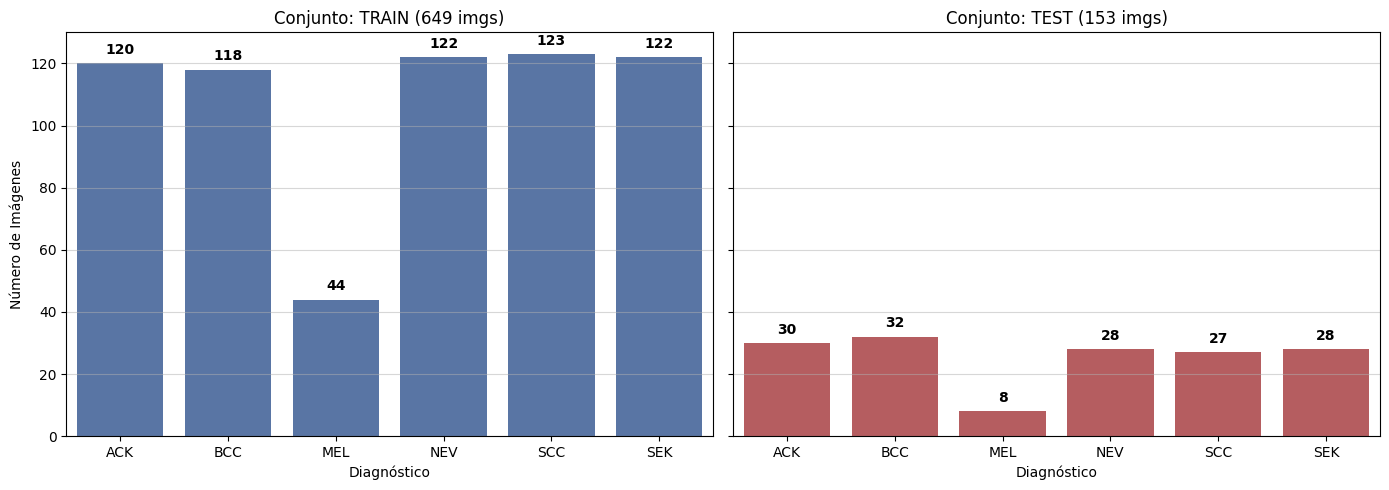


Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


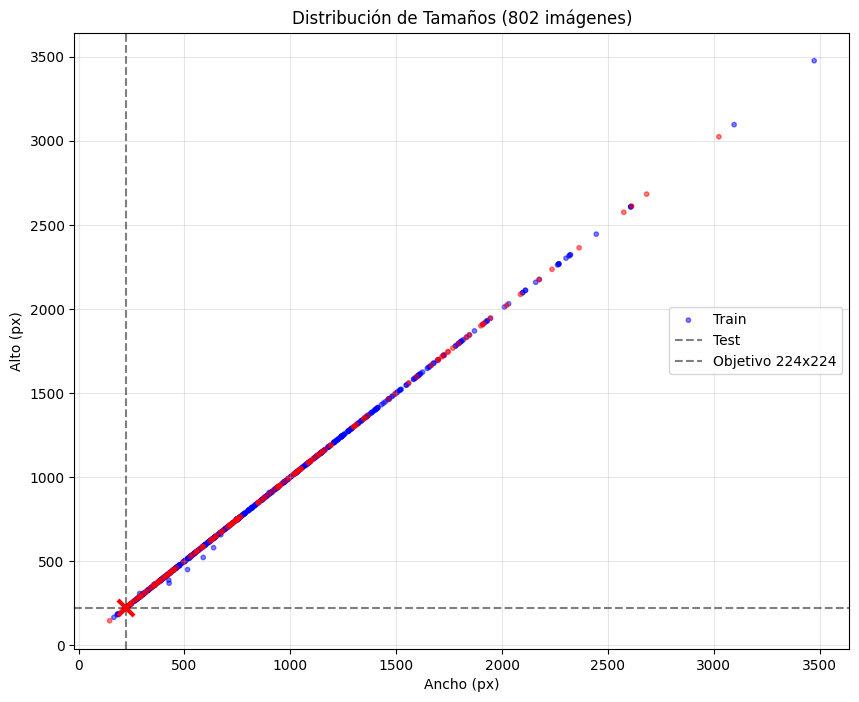

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm

RUTA_RAIZ = "../../Datos/images/SPLIT_MULTICLASE"
splits = ["train", "test"]
colores = ["#4c72b0", "#c44e52"]

# --- Distribución de clases ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, split in enumerate(splits):
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    conteo = {c: len(os.listdir(os.path.join(split_path, c))) for c in clases}
    total = sum(conteo.values())

    sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), ax=axes[i], color=colores[i])
    axes[i].set_title(f"Conjunto: {split.upper()} ({total} imgs)")
    axes[i].set_xlabel("Diagnóstico")
    axes[i].grid(axis="y", alpha=0.5)
    axes[i].set_ylim(0, 130)

    for idx, (clase, valor) in enumerate(conteo.items()):
        axes[i].text(idx, valor + 3, str(valor), ha="center", fontweight="bold")

axes[0].set_ylabel("Número de Imágenes")
plt.tight_layout()
plt.show()

# --- Tamaño de imágenes ---
anchos = []
altos = []
colores_puntos = []
mapa_colores = {"train": "blue", "test": "red"}

for split in splits:
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    for clase in clases:
        clase_path = os.path.join(split_path, clase)
        archivos = [f for f in os.listdir(clase_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        for nombre in tqdm(archivos, desc=f"{split}/{clase}", leave=False):
            ruta_completa = os.path.join(clase_path, nombre)
            with Image.open(ruta_completa) as img:
                w, h = img.size
                anchos.append(w)
                altos.append(h)
                colores_puntos.append(mapa_colores[split])

plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)
plt.axvline(224, color="k", linestyle="--", alpha=0.5)
plt.axhline(224, color="k", linestyle="--", alpha=0.5)
plt.plot(224, 224, "rx", markersize=12, markeredgewidth=3)
plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(["Train", "Test", "Objetivo 224x224"])
plt.grid(True, alpha=0.3)

print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()


### Conclusiones del EDA

**Problemas identificados:**
- **Desbalance severo en MEL**: Solo 6.8% del train. Los modelos tenderán a ignorar esta clase.
- **Pocos datos**: 649 imágenes es poco para entrenar CNNs desde cero → Transfer Learning obligatorio.

**Estrategia de evaluación:**
- **F1-Macro** como métrica principal: Promedia el F1 de cada clase sin ponderar por tamaño, así penaliza si el modelo falla en MEL.
- **Recall de MEL**: Prioridad clínica. Es peor no detectar un melanoma (falso negativo) que dar una falsa alarma.
- **Matriz de confusión**: Para ver con qué clases se confunde MEL.

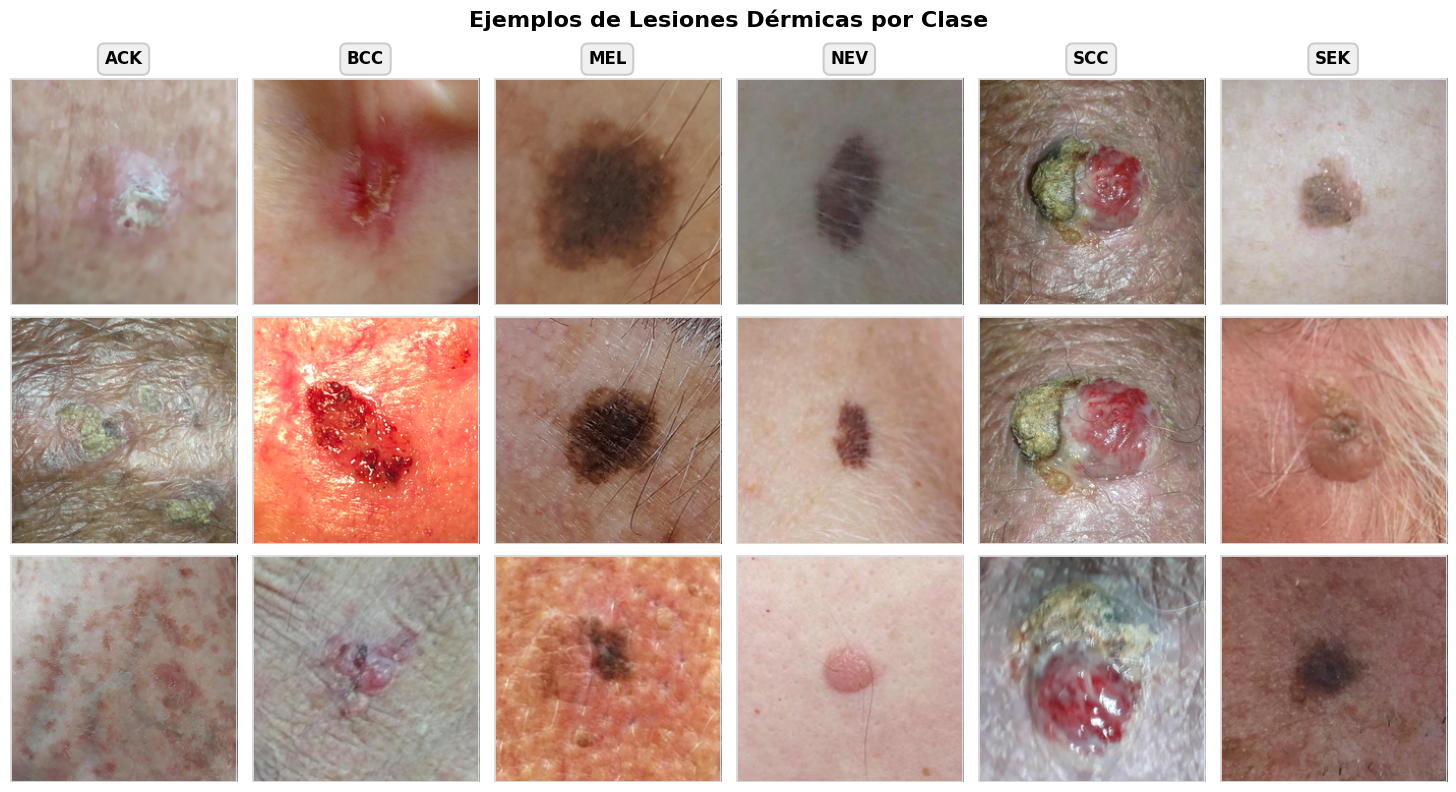

In [36]:
import os
import matplotlib.pyplot as plt
from PIL import Image

DATA_PATH = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/MULTICLASE"

clases = sorted(os.listdir(DATA_PATH))
n_imgs = 3

# Crear figura profesional (3 filas, n_clases columnas)
fig, axes = plt.subplots(n_imgs, len(clases), figsize=(2.5*len(clases), 8))
fig.patch.set_facecolor('white')

for i, clase in enumerate(clases):
    clase_path = os.path.join(DATA_PATH, clase)
    imgs = sorted(os.listdir(clase_path))[:n_imgs]
    
    for j, img_name in enumerate(imgs):
        img_path = os.path.join(clase_path, img_name)
        img = Image.open(img_path).resize((224, 224), Image.Resampling.LANCZOS)
        
        ax = axes[j, i]
        ax.imshow(img)
        ax.axis('off')
        
        # Marco profesional
        rect = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                            fill=False, edgecolor='#dddddd', 
                            linewidth=2, linestyle='-')
        ax.add_patch(rect)
        
        # Título de clase solo en la primera fila
        if j == 0:
            ax.set_title(clase, fontsize=12, fontweight='bold', pad=10,
                        bbox=dict(boxstyle='round,pad=0.4', 
                                facecolor='#f0f0f0', 
                                edgecolor='#cccccc',
                                linewidth=1.5))

# Título principal (más arriba)
fig.suptitle('Ejemplos de Lesiones Dérmicas por Clase', 
             fontsize=16, fontweight='bold', y=0.985)

# Ajustar espaciado (más separación arriba)
plt.subplots_adjust(left=0.02, right=0.98, top=0.9, bottom=0.02, 
                    wspace=0.05, hspace=0.05)
plt.show()

## 3. Hiperparametrización con Optuna

Usamos **Optuna** para buscar hiperparámetros óptimos con optimización bayesiana.

**Configuración:**
- 20 trials por modelo
- 5-Fold Cross-Validation estratificado
- Métrica: `0.5 × F1_Macro + 0.5 × Cohen_Kappa`
- Pruning de trials malos para ahorrar tiempo

**Modelos probados:**
- **ResNet18**: Congelamos capas iniciales, fine-tuning de layer4 + FC
- **DenseNet121**: Congelamos denseblocks 1-3, fine-tuning de denseblock4 + FC
- **YOLO26x**: Sin congelación (fine-tuning completo)

**Hiperparámetros buscados:**
- Learning rates (backbone y head)
- Weight decay, dropout
- Batch size, optimizer

📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS

🔍 Cargando estudios de Optuna...
  ✅ ResNet18: 20 trials
  ✅ DenseNet121: 20 trials
  ✅ YOLO26x: 30 trials

📈 Generando gráfica: Evolución de scores...



🎨 Generando gráficas: Combinaciones de hiperparámetros...


  ✅ ResNet18


  ✅ DenseNet121


  ✅ YOLO26x

📊 ESTADÍSTICAS DE TRIALS

     Modelo  Total Trials  Completados  Podados  Fallidos % Completados
   ResNet18            20           12        8         0         60.0%
DenseNet121            20           17        3         0         85.0%
    YOLO26x            30           10       20         0         33.3%

🏆 MEJORES HIPERPARÁMETROS POR MODELO

────────────────────────────────────────────────────────────────────────────────
📌 RESNET18
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.5600
🔢 Mejor Trial: #0

📝 Hiperparámetros:
   • batch_size          : 16
   • dropout             : 0.300000
   • lr_backbone         : 0.000131
   • lr_head             : 0.000437
   • weight_decay        : 0.002365

────────────────────────────────────────────────────────────────────────────────
📌 DENSENET121
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.5550
🔢 Mejor Trial: #14

📝 Hiperp

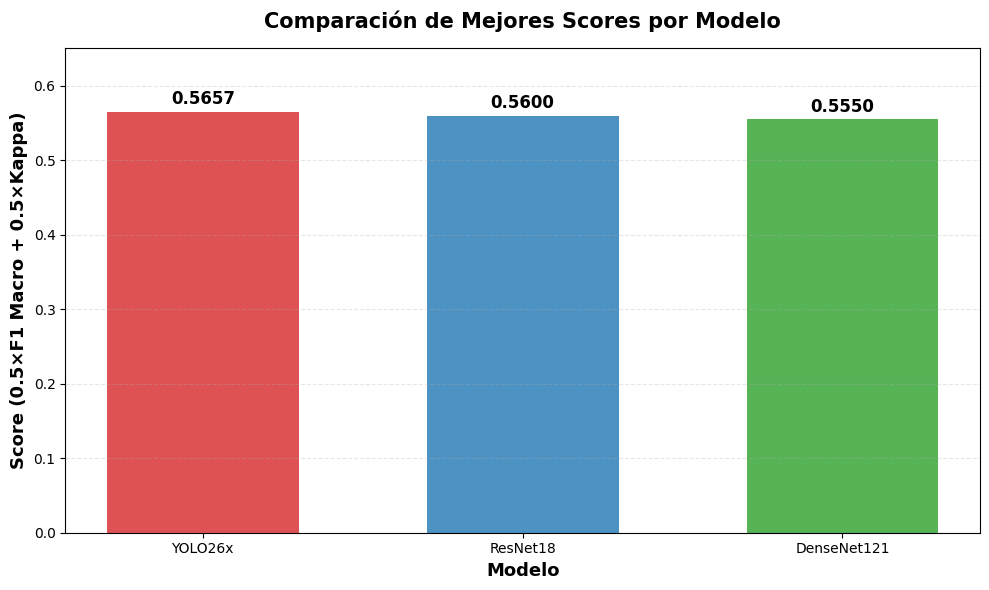


✅ VISUALIZACIÓN COMPLETADA



In [2]:
"""
Visualización de hiperparametrización - ResNet18, DenseNet121, YOLO26x
"""

import optuna
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Configuración
DB_RESNET_DENSENET = "hyperparameters/hyperparameter_tuning.db"
DB_YOLO = "hyperparameters/yolo_tuning.db"

print("="*80)
print("📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS")
print("="*80)

# ============================================================================
# 1. CARGAR ESTUDIOS
# ============================================================================

print("\n🔍 Cargando estudios de Optuna...")

storage_resnet = f"sqlite:///{DB_RESNET_DENSENET}"
try:
    study_resnet = optuna.load_study(study_name="resnet18_tuning", storage=storage_resnet)
    print(f"  ✅ ResNet18: {len(study_resnet.trials)} trials")
except:
    print(f"  ❌ ResNet18 no encontrado")
    study_resnet = None

try:
    study_densenet = optuna.load_study(study_name="densenet121_tuning", storage=storage_resnet)
    print(f"  ✅ DenseNet121: {len(study_densenet.trials)} trials")
except:
    print(f"  ❌ DenseNet121 no encontrado")
    study_densenet = None

storage_yolo = f"sqlite:///{DB_YOLO}"
try:
    study_yolo = optuna.load_study(study_name="yolo26x-cls_tuning", storage=storage_yolo)
    print(f"  ✅ YOLO26x: {len(study_yolo.trials)} trials")
except:
    print(f"  ❌ YOLO26x no encontrado")
    study_yolo = None

def get_completed_trials(study):
    if study is None:
        return []
    return [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

# ============================================================================
# 2. GRÁFICA: EVOLUCIÓN DE SCORES
# ============================================================================

print("\n📈 Generando gráfica: Evolución de scores...")

studies = {
    'ResNet18': study_resnet,
    'DenseNet121': study_densenet,
    'YOLO26x': study_yolo
}

colors = {'ResNet18': '#1f77b4', 'DenseNet121': '#2ca02c', 'YOLO26x': '#d62728'}

fig = go.Figure()

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    trial_numbers = [t.number for t in completed]
    scores = [t.value for t in completed]
    
    # Trials
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=scores,
        mode='markers+lines',
        name=f'{model_name}',
        marker=dict(size=8, color=colors[model_name]),
        line=dict(color=colors[model_name], width=2, dash='dot'),
        opacity=0.6
    ))
    
    # Best so far
    best_so_far = []
    current_best = -float('inf')
    for score in scores:
        current_best = max(current_best, score)
        best_so_far.append(current_best)
    
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=best_so_far,
        mode='lines',
        name=f'{model_name} (best)',
        line=dict(color=colors[model_name], width=3),
        opacity=0.9
    ))

fig.update_layout(
    title='Evolución de Scores en Hiperparametrización',
    xaxis_title='Trial Number',
    yaxis_title='Score (0.5×F1 Macro + 0.5×Kappa)',
    hovermode='closest',
    template='plotly_white',
    height=600,
    font=dict(size=12)
)
fig.show()

# ============================================================================
# 3. GRÁFICAS: PARALLEL COORDINATES (Combinaciones de hiperparámetros)
# ============================================================================

print("\n🎨 Generando gráficas: Combinaciones de hiperparámetros...")

for model_name, study in studies.items():
    if study is None or len(get_completed_trials(study)) < 3:
        continue
    
    try:
        fig = optuna.visualization.plot_parallel_coordinate(study)
        fig.update_layout(
            title=f'Combinaciones de Hiperparámetros - {model_name}',
            height=500
        )
        fig.show()
        print(f"  ✅ {model_name}")
    except Exception as e:
        print(f"  ⚠️  Error en {model_name}: {e}")

# ============================================================================
# 4. TABLA: ESTADÍSTICAS DE TRIALS
# ============================================================================

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DE TRIALS")
print("="*80)

stats_data = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    total = len(study.trials)
    pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
    failed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.FAIL)
    
    stats_data.append({
        'Modelo': model_name,
        'Total Trials': total,
        'Completados': len(completed),
        'Podados': pruned,
        'Fallidos': failed,
        '% Completados': f"{len(completed)/total*100:.1f}%"
    })

df_stats = pd.DataFrame(stats_data)
print("\n" + df_stats.to_string(index=False))

# ============================================================================
# 5. RESUMEN: MEJORES HIPERPARÁMETROS
# ============================================================================

print("\n" + "="*80)
print("🏆 MEJORES HIPERPARÁMETROS POR MODELO")
print("="*80)

results_summary = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    best_trial = study.best_trial
    
    print(f"\n{'─'*80}")
    print(f"📌 {model_name.upper()}")
    print(f"{'─'*80}")
    print(f"🏆 Mejor Score: {best_trial.value:.4f}")
    print(f"🔢 Mejor Trial: #{best_trial.number}")
    print(f"\n📝 Hiperparámetros:")
    
    for param, value in sorted(best_trial.params.items()):
        if isinstance(value, float):
            print(f"   • {param:20s}: {value:.6f}")
        else:
            print(f"   • {param:20s}: {value}")
    
    results_summary.append({
        'Modelo': model_name,
        'Score': best_trial.value
    })

# ============================================================================
# 6. GRÁFICA: COMPARACIÓN DE SCORES (MATPLOTLIB)
# ============================================================================

if results_summary:
    print("\n" + "="*80)
    print("📊 COMPARACIÓN FINAL")
    print("="*80)
    
    df = pd.DataFrame(results_summary).sort_values('Score', ascending=False)
    print("\n" + df.to_string(index=False))
    
    # Gráfica con matplotlib
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bar_colors = [colors.get(m, 'gray') for m in df['Modelo']]
    bars = ax.bar(df['Modelo'], df['Score'], color=bar_colors, alpha=0.8, width=0.6)
    
    # Valores encima de barras
    for bar, score in zip(bars, df['Score']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{score:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    ax.set_ylabel('Score (0.5×F1 Macro + 0.5×Kappa)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=13, fontweight='bold')
    ax.set_title('Comparación de Mejores Scores por Modelo', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, max(df['Score']) * 1.15)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ VISUALIZACIÓN COMPLETADA")
print("="*80 + "\n")

**Resultados de Optuna:**
- YOLO tiene alto ratio de pruning (66.7%) por su espacio de búsqueda más complejo
- DenseNet es más estable (85% trials completados)
- Los tres modelos obtienen scores similares (~0.58-0.59), sugiriendo capacidad comparable

## 4. Carga de Datos y Preparación de Folds

### Estructura de Directorios

```
SPLIT_MULTICLASE/
├── train/
│   ├── ACK/ → clase 0
│   ├── BCC/ → clase 1
│   ├── MEL/ → clase 2
│   ├── NEV/ → clase 3
│   ├── SCC/ → clase 4
│   └── SEK/ → clase 5
└── test/
```

### Data Augmentation

**Train:** Augmentation agresivo (crops, flips, variación HSV, random erasing)
**Val/Test:** Solo resize a 224×224 + normalización ImageNet

### 5-Fold Cross-Validation

Usamos StratifiedKFold para mantener la proporción de clases en cada fold (~80% train / 20% val por iteración). Seed fijo (42) para reproducibilidad.

In [1]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from ultralytics.data.augment import classify_augmentations, classify_transforms
from sklearn.model_selection import StratifiedKFold
import random
import numpy as np

SEED = 42

SEED = 42
random.seed(SEED)             # Python nativo
np.random.seed(SEED)          # Numpy (arrays y mates)
torch.manual_seed(SEED)       # PyTorch CPU
torch.cuda.manual_seed(SEED)  # PyTorch GPU
torch.cuda.manual_seed_all(SEED) # Multi-GPU
torch.backends.cudnn.deterministic = True # Obliga a CUDA a ser determinista
torch.backends.cudnn.benchmark = False    # Desactiva optimizaciones que meten aleatoriedad

RUTA_BASE = "../../Datos/images/SPLIT_MULTICLASE"
BATCH_SIZE = 16 # Tamaño del batch, le entran 64 imagenes -> Forward -> Calculo Error -> Backprop -> Update y vuelta a empezar
IMG_SIZE = 224 # Tamaño de la imagen estándar por ImageNet
K_FOLDS = 5 # Cantidad de folds que haremos para evaluar
MEAN = [0.485, 0.456, 0.406] # Media de cada canal de la imagen obtenidos por el dataset imagenet
STD = [0.229, 0.224, 0.225] # Desviación estándar de cada canal de la imagen obtenidos por el dataset imagenet

# Pipeline de entrenamiento con augmentation
train_pipeline = classify_augmentations(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    scale=(0.5, 1.0), # En cada época, recorta un trozo de la imagen que sea entre el 50% y el 100% del tamaño original y hazle zoom
    hflip=0.5, # 50% de probabilidad de voltear la imagen tipo espejo (izquierda-derecha)
    vflip=0.5, # 50% de probabilidad de voltear la imagen tipo espejo (arriba-abajo)
    # Cambia aleatoriamente el Tono (H), Saturación (S) y Brillo (V)
    hsv_h=0.015, 
    hsv_s=0.7,
    hsv_v=0.4,
    # Con un 30% de probabilidad, borra un rectángulo aleatorio de la imagen (lo pone gris o ruido)
    erasing=0.3,
)

# Pipeline de validacion/test (determinista), si pasas una imagen por esta transformación siempre sealdrá la misma foto
val_test_pipeline = classify_transforms(
    #Usamos EXACTAMENTE los mismos valores de normalización que en el entrenamiento
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    #Es el algoritmo matemático para cambiar el tamaño de la imagen (Resize), nos aseguramos que la imagen no se distorsione
    interpolation="BILINEAR"
)

# Dataset de train COMPLETO 
full_train_dataset = datasets.ImageFolder( # ImageFolder asigna una ertiqueta numérica a cada clase que haya dividida en carpetas
    f"{RUTA_BASE}/train", # sin transformaciones, cuando asignemos los folds le aplicaremos transformaciones diferentes
    transform=None
)


targets = full_train_dataset.targets #Extrae las etiquetas asociadas a cada imagen (tipo de lesión cutánea)
print(f"Train total: {len(full_train_dataset)} imgs, Clases: {full_train_dataset.classes}")

# Dataset de test (fijo, no cambia entre folds)
test_dataset = datasets.ImageFolder( 
    f"{RUTA_BASE}/test",
    transform=val_test_pipeline #aqui si hacemos la transformación determinista
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
print(f"Test: {len(test_dataset)} imgs")

# Wrapper para aplicar transform distinto a cada subset (necesario para 5-fold)
class SubsetConTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset # el dataset completo que le entra
        self.indices = list(indices) # la lista de fotos que le tocan al fold actual
        self.transform = transform # la transformación que le toca al fold actual

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]] #aqui sel.indices es el id de la foto y idx es la posición del subset dividido train/val del fold
        if self.transform is not None: # si existe un tipo de transformación
            img = self.transform(img) # aqui le aplica la transformación
        return img, label

    def __len__(self):
        return len(self.indices)

# Objeto KFold estratificado
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED) #hacemos shuffle para evitar que el orden afecte, n_splits es el número de folds y StratifiedKFold es el método que divide en train y val

# Aqui solo miramos las etiquetas y hacemos el 5-fold para ver cuantas imágenes tiene cada fold
print(f"\n5-Fold CV preparado. En cada fold:")
for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)): # targets es una lista de enteros que indica la clase de cada imagen, con sk.split la divide en train y val 5 veces
    print(f"  Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}")

Train total: 649 imgs, Clases: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
Test: 153 imgs

5-Fold CV preparado. En cada fold:
  Fold 1: train=519, val=130
  Fold 2: train=519, val=130
  Fold 3: train=519, val=130
  Fold 4: train=519, val=130
  Fold 5: train=520, val=129


La división 5-fold genera ~520 imgs de train y ~130 de val por iteración. El test (153 imgs) permanece separado hasta la evaluación final.

### Visualización de Data Augmentation

Verificamos que las augmentations funcionan correctamente:

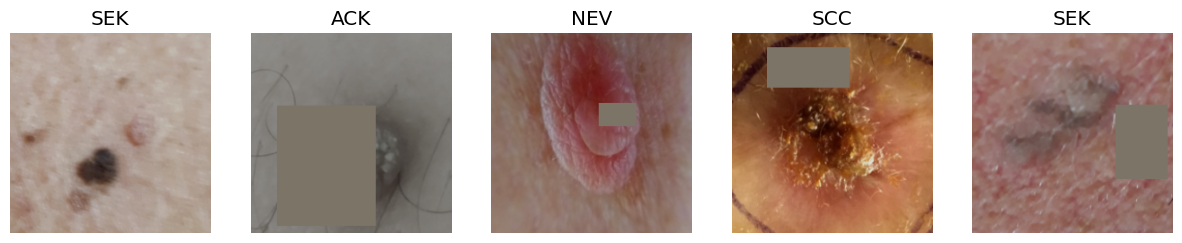

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Loader temporal con el pipeline de augmentation para visualizar
viz_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_pipeline)
viz_loader = DataLoader(viz_dataset, batch_size=BATCH_SIZE, shuffle=True)
imgs, labels = next(iter(viz_loader))

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    plt.title(full_train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

del viz_dataset, viz_loader

Se aprecian flips, random erasing (rectángulos grises) y crops aleatorios. Las transformaciones son realistas y no distorsionan las características diagnósticas.

## 5. Pipeline de Entrenamiento y Evaluación

Definimos funciones reutilizables para todos los modelos:

- **Métricas**: F1-macro, accuracy, precision, recall, kappa
- **Visualización**: Curvas de entrenamiento, matrices de confusión
- **Smart Saving**: Guarda automáticamente el modelo con mejor F1-Macro en validación

El pipeline completo (`lanzar_experimento_kfold()`) entrena 5 folds, calcula class weights por fold, y genera resumen estadístico (media ± std).

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def obtener_predicciones(model, loader, device):
    """Obtiene predicciones, etiquetas reales y probabilidades de un modelo."""
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_probs)


def calcular_metricas(y_true, y_pred):
    """Calcula todas las metricas a partir de etiquetas reales y predichas."""
    return {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
    }


def mostrar_reporte_completo(y_true, y_pred, classes, titulo, mostrar_cm=True):
    """Muestra matriz de confusion, classification report y todas las metricas."""
    metricas = calcular_metricas(y_true, y_pred)

    if mostrar_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes)
        plt.title(f'Matriz de Confusion - {titulo}')
        plt.ylabel('Etiqueta Real')
        plt.xlabel('Prediccion')
        plt.show()

    print(f"\n{'='*70}")
    print(f"REPORTE: {titulo}")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print(f"{'─'*70}")
    print(f"  Accuracy:           {metricas['accuracy']:.4f}")
    print(f"  F1 Macro:           {metricas['f1_macro']:.4f}")
    print(f"  F1 Weighted:        {metricas['f1_weighted']:.4f}")
    print(f"  Precision Macro:    {metricas['precision_macro']:.4f}")
    print(f"  Precision Weighted: {metricas['precision_weighted']:.4f}")
    print(f"  Recall Macro:       {metricas['recall_macro']:.4f}")
    print(f"  Recall Weighted:    {metricas['recall_weighted']:.4f}")
    print(f"  Cohen's Kappa:      {metricas['kappa']:.4f}")
    print(f"{'='*70}")

    return metricas


# ============================================================
# FUNCIONES DE VISUALIZACION
# ============================================================

def plot_training_history(historial, titulo=""):
    """Curvas de entrenamiento de un solo run."""
    epochs = range(1, len(historial['train_loss']) + 1)

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
    plt.title(f'Loss - {titulo}')
    plt.xlabel('Epocas')
    plt.ylabel('CrossEntropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Val F1 (Macro)', color='green', marker='o', linewidth=2)
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label=f'Mejor: {max(historial["val_f1"]):.4f}')
    plt.title(f'F1-Score - {titulo}')
    plt.xlabel('Epocas')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_kfold_history(historiales, nombre_exp):
    """Curvas promediadas de K folds con banda de desviacion estandar."""
    max_epochs = max(len(h['train_loss']) for h in historiales)

    def pad(lst, length):
        return lst + [lst[-1]] * (length - len(lst))

    train_losses = np.array([pad(h['train_loss'], max_epochs) for h in historiales])
    val_losses = np.array([pad(h['val_loss'], max_epochs) for h in historiales])
    val_f1s = np.array([pad(h['val_f1'], max_epochs) for h in historiales])

    epochs = range(1, max_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Loss
    ax = axes[0]
    mean_tl, std_tl = train_losses.mean(axis=0), train_losses.std(axis=0)
    mean_vl, std_vl = val_losses.mean(axis=0), val_losses.std(axis=0)
    ax.plot(epochs, mean_tl, 'b-', linewidth=2, label='Train Loss (media)')
    ax.fill_between(epochs, mean_tl - std_tl, mean_tl + std_tl, alpha=0.2, color='blue')
    ax.plot(epochs, mean_vl, 'r--', linewidth=2, label='Val Loss (media)')
    ax.fill_between(epochs, mean_vl - std_vl, mean_vl + std_vl, alpha=0.2, color='red')
    ax.set_title(f'Loss Promedio - {nombre_exp}')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # F1
    ax = axes[1]
    mean_f1, std_f1 = val_f1s.mean(axis=0), val_f1s.std(axis=0)
    ax.plot(epochs, mean_f1, 'g-', linewidth=2, label='Val F1 Macro (media)')
    ax.fill_between(epochs, mean_f1 - std_f1, mean_f1 + std_f1, alpha=0.2, color='green')
    ax.set_title(f'F1-Score Promedio - {nombre_exp}')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def mostrar_matrices_confusion_folds(predicciones_por_fold, classes, nombre_exp):
    """Muestra las 5 matrices de confusión de validación en una sola figura."""
    n_folds = len(predicciones_por_fold)
    fig, axes = plt.subplots(1, n_folds, figsize=(5*n_folds, 5))
    if n_folds == 1:
        axes = [axes]

    for fold_idx, (y_true, y_pred) in enumerate(predicciones_por_fold):
        cm = confusion_matrix(y_true, y_pred)
        metricas = calcular_metricas(y_true, y_pred)

        ax = axes[fold_idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(f'Fold {fold_idx+1}\nF1={metricas["f1_macro"]:.3f} | Acc={metricas["accuracy"]:.3f}')
        ax.set_ylabel('Real' if fold_idx == 0 else '')
        ax.set_xlabel('Predicción')

    plt.suptitle(f'Matrices de Confusión (Validación) - {nombre_exp}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ============================================================
# FUNCION DE ENTRENAMIENTO (un fold)
# ============================================================

def entrenar_modelo(model, train_loader, val_loader, criterion, optimizer, device, epochs=25, nombre_archivo="mejor_modelo.pth"):
    """Entrena un modelo y guarda el mejor segun F1 macro en validacion."""
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'train_f1': []}
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0.0
        y_true_train, y_pred_train = [], []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_f1 = f1_score(y_true_train, y_pred_train, average='macro')

        # Validation
        model.eval()
        val_loss = 0.0
        y_true, y_pred = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_f1 = f1_score(y_true, y_pred, average='macro')

        historial['train_loss'].append(epoch_train_loss)
        historial['train_f1'].append(epoch_train_f1)
        historial['val_loss'].append(epoch_val_loss)
        historial['val_f1'].append(epoch_val_f1)

        marcador = ""
        if epoch_val_f1 > best_f1:
            best_f1 = epoch_val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            marcador = " ** Mejor!"

        print(f"  Ep {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.3f} | Train F1: {epoch_train_f1:.4f} | Val Loss: {epoch_val_loss:.3f} | Val F1: {epoch_val_f1:.4f}{marcador}")

    print(f"  Mejor F1 Val: {best_f1:.4f}")
    model.load_state_dict(best_model_wts)
    return model, historial


# ============================================================
# PIPELINE 5-FOLD CV (SIN EVALUACION EN TEST)
# ============================================================

def lanzar_experimento_kfold(crear_modelo_fn, nombre_exp, device, epochs=25):
    """
    Ejecuta el pipeline de 5-Fold Cross-Validation SIN evaluar en TEST.
    La evaluación en test se hace al final del notebook.

    Args:
        crear_modelo_fn: funcion(num_classes, device) -> (model, optimizer)
        nombre_exp: nombre del experimento
        device: torch device
        epochs: epocas por fold

    Usa variables globales: full_train_dataset, targets, skf,
        train_pipeline, val_test_pipeline, BATCH_SIZE, SubsetConTransform

    Returns:
        dict con metricas, historiales, modelos y predicciones de validación
    """
    print(f"\n{'='*60}")
    print(f"EXPERIMENTO 5-FOLD CV: {nombre_exp}")
    print(f"{'='*60}")

    num_classes = len(full_train_dataset.classes)
    classes = full_train_dataset.classes

    metricas_folds = []
    historiales = []
    modelos_state_dicts = []
    predicciones_val_por_fold = []  # (y_true, y_pred) por fold
    probs_val_por_fold = []  # probabilidades para ensemble

    # Guardar indices de validación para reconstruir todas las predicciones
    indices_val_todos = []
    y_true_val_todos = []
    y_pred_val_todos = []
    y_probs_val_todos = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
        print(f"\n{'─'*50}")
        print(f"FOLD {fold+1}/{skf.n_splits} | Train: {len(train_idx)} | Val: {len(val_idx)}")
        print(f"{'─'*50}")

        # --- DataLoaders del fold ---
        fold_train = SubsetConTransform(full_train_dataset, train_idx, train_pipeline)
        fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)

        fold_train_loader = DataLoader(
            fold_train, batch_size=BATCH_SIZE, shuffle=True,
            num_workers=8, pin_memory=True
        )
        fold_val_loader = DataLoader(
            fold_val, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=4, pin_memory=True
        )

        # --- Pesos de clase para este fold ---
        fold_targets = [targets[i] for i in train_idx]
        class_counts = np.bincount(fold_targets, minlength=num_classes).astype(float)
        weights = 1.0 / class_counts
        weights = weights / weights.sum() * num_classes
        class_weights = torch.FloatTensor(weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        # --- Modelo y optimizador frescos ---
        model, optimizer = crear_modelo_fn(num_classes, device)

        # --- Entrenar ---
        model, historial = entrenar_modelo(
            model, fold_train_loader, fold_val_loader,
            criterion, optimizer, device, epochs,
            nombre_archivo=f"{nombre_exp}_fold{fold+1}.pth"
        )

        # --- Metricas del fold en validacion ---
        y_true_val, y_pred_val, y_probs_val = obtener_predicciones(model, fold_val_loader, device)
        fold_metricas = calcular_metricas(y_true_val, y_pred_val)

        print(f"  >> Fold {fold+1} Val: F1={fold_metricas['f1_macro']:.4f} | "
              f"Acc={fold_metricas['accuracy']:.4f} | Kappa={fold_metricas['kappa']:.4f}")

        metricas_folds.append(fold_metricas)
        historiales.append(historial)
        modelos_state_dicts.append(copy.deepcopy(model.state_dict()))
        predicciones_val_por_fold.append((y_true_val, y_pred_val))

        # Acumular para evaluación global de validación
        y_true_val_todos.extend(y_true_val)
        y_pred_val_todos.extend(y_pred_val)
        y_probs_val_todos.extend(y_probs_val)
        indices_val_todos.extend(val_idx)

    # ============================================================
    # RESUMEN CROSS-VALIDATION
    # ============================================================
    print(f"\n{'='*60}")
    print(f"RESUMEN 5-FOLD CV: {nombre_exp}")
    print(f"{'='*60}")

    metric_names = ['f1_macro', 'f1_weighted', 'accuracy',
                    'precision_macro', 'precision_weighted',
                    'recall_macro', 'recall_weighted', 'kappa']

    tabla = {}
    for metric in metric_names:
        valores = [m[metric] for m in metricas_folds]
        tabla[metric] = [round(v, 4) for v in valores] + [round(np.mean(valores), 4), round(np.std(valores), 4)]

    cols = [f"Fold {i+1}" for i in range(skf.n_splits)] + ["Media", "Std"]
    df_resumen = pd.DataFrame(tabla, index=cols).T
    print(df_resumen.to_string())

    # --- Curvas promediadas ---
    print(f"\nCurvas de entrenamiento promediadas:")
    plot_kfold_history(historiales, nombre_exp)

    # --- Curvas individuales por fold ---
    for i, h in enumerate(historiales):
        plot_training_history(h, titulo=f"{nombre_exp} - Fold {i+1}")

    # ============================================================
    # MATRICES DE CONFUSION POR FOLD (VALIDACION)
    # ============================================================
    print(f"\n{'='*60}")
    print(f"MATRICES DE CONFUSION POR FOLD (VALIDACION) - {nombre_exp}")
    print(f"{'='*60}")

    mostrar_matrices_confusion_folds(predicciones_val_por_fold, classes, nombre_exp)

    # ============================================================
    # EVALUACION GLOBAL EN VALIDACION (todos los folds combinados)
    # ============================================================
    print(f"\n{'='*60}")
    print(f"EVALUACION GLOBAL VALIDACION (todos los folds) - {nombre_exp}")
    print(f"{'='*60}")

    y_true_val_todos = np.array(y_true_val_todos)
    y_pred_val_todos = np.array(y_pred_val_todos)

    metricas_val_global = mostrar_reporte_completo(
        y_true_val_todos, y_pred_val_todos, classes,
        f"VALIDACION GLOBAL - {nombre_exp}"
    )

    # ============================================================
    # ENSEMBLE DE 5 FOLDS EVALUADO EN VALIDACION
    # ============================================================
    print(f"\n{'='*60}")
    print(f"ENSEMBLE {skf.n_splits} FOLDS - VALIDACION - {nombre_exp}")
    print(f"{'='*60}")
    print("Nota: Cada muestra de validación solo fue vista por 1 modelo (su fold).")
    print("Para ensemble en validación, usamos las probabilidades del modelo que predijo cada muestra.")

    # Las predicciones ya son del modelo correcto para cada muestra
    # El ensemble en validación es equivalente a las predicciones individuales
    # porque cada muestra solo tiene predicción de un modelo

    y_probs_val_todos = np.array(y_probs_val_todos)
    y_pred_ensemble_val = np.argmax(y_probs_val_todos, axis=1)

    # Verificar que son iguales (deben serlo)
    print(f"Verificación: predicciones ensemble == predicciones individuales: {np.array_equal(y_pred_ensemble_val, y_pred_val_todos)}")

    # ============================================================
    # MEJOR FOLD
    # ============================================================
    f1_scores = [m['f1_macro'] for m in metricas_folds]
    best_fold = int(np.argmax(f1_scores))

    print(f"\n{'='*60}")
    print(f"MEJOR FOLD: {best_fold+1} (F1 Macro Val = {f1_scores[best_fold]:.4f})")
    print(f"{'='*60}")

    return {
        'metricas_folds': metricas_folds,
        'historiales': historiales,
        'modelos_state_dicts': modelos_state_dicts,
        'best_fold': best_fold,
        'df_resumen': df_resumen,
        'predicciones_val_por_fold': predicciones_val_por_fold,
        'metricas_val_global': metricas_val_global,
        'classes': classes,
        'num_classes': num_classes,
    }


print("Funciones cargadas (SIN evaluación en test).")


Funciones cargadas (SIN evaluación en test).


## 6. Experimentos con Transfer Learning

### 6.1 ResNet18

**Arquitectura:** 18 capas con conexiones residuales. Cargamos pesos de ImageNet, congelamos todo excepto layer4, y añadimos un clasificador con dropout.

**Hiperparámetros (Optuna):**

| Parámetro | Valor |
|-----------|-------|
| lr_backbone | 0.000131 |
| lr_head | 0.000437 |
| weight_decay | 0.002365 |
| dropout | 0.3 |
| batch_size | 16 |

El clasificador tiene mayor LR que el backbone porque debe aprender desde cero.

Usando device: cuda

EXPERIMENTO 5-FOLD CV: ResNet18_5Fold

──────────────────────────────────────────────────
FOLD 1/5 | Train: 519 | Val: 130
──────────────────────────────────────────────────
  Ep 1/15 | Train Loss: 1.691 | Train F1: 0.2656 | Val Loss: 1.335 | Val F1: 0.4368 ** Mejor!
  Ep 2/15 | Train Loss: 1.294 | Train F1: 0.4807 | Val Loss: 1.238 | Val F1: 0.5566 ** Mejor!
  Ep 3/15 | Train Loss: 1.190 | Train F1: 0.5017 | Val Loss: 1.288 | Val F1: 0.4717
  Ep 4/15 | Train Loss: 1.101 | Train F1: 0.5355 | Val Loss: 1.202 | Val F1: 0.5658 ** Mejor!
  Ep 5/15 | Train Loss: 0.971 | Train F1: 0.5925 | Val Loss: 1.266 | Val F1: 0.5589
  Ep 6/15 | Train Loss: 0.994 | Train F1: 0.5956 | Val Loss: 1.185 | Val F1: 0.5923 ** Mejor!
  Ep 7/15 | Train Loss: 0.902 | Train F1: 0.6253 | Val Loss: 1.201 | Val F1: 0.5375
  Ep 8/15 | Train Loss: 0.805 | Train F1: 0.6928 | Val Loss: 1.181 | Val F1: 0.5371
  Ep 9/15 | Train Loss: 0.707 | Train F1: 0.7233 | Val Loss: 1.171 | Val F1: 0.5352
  Ep 10/1

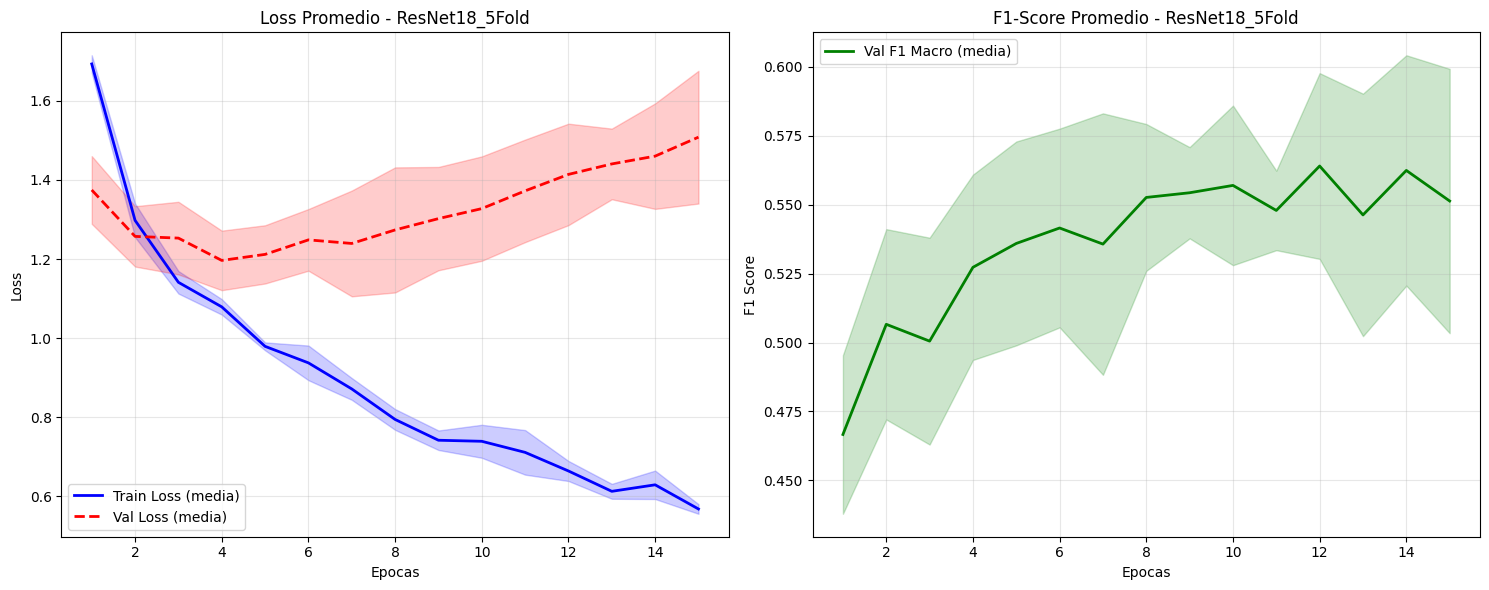

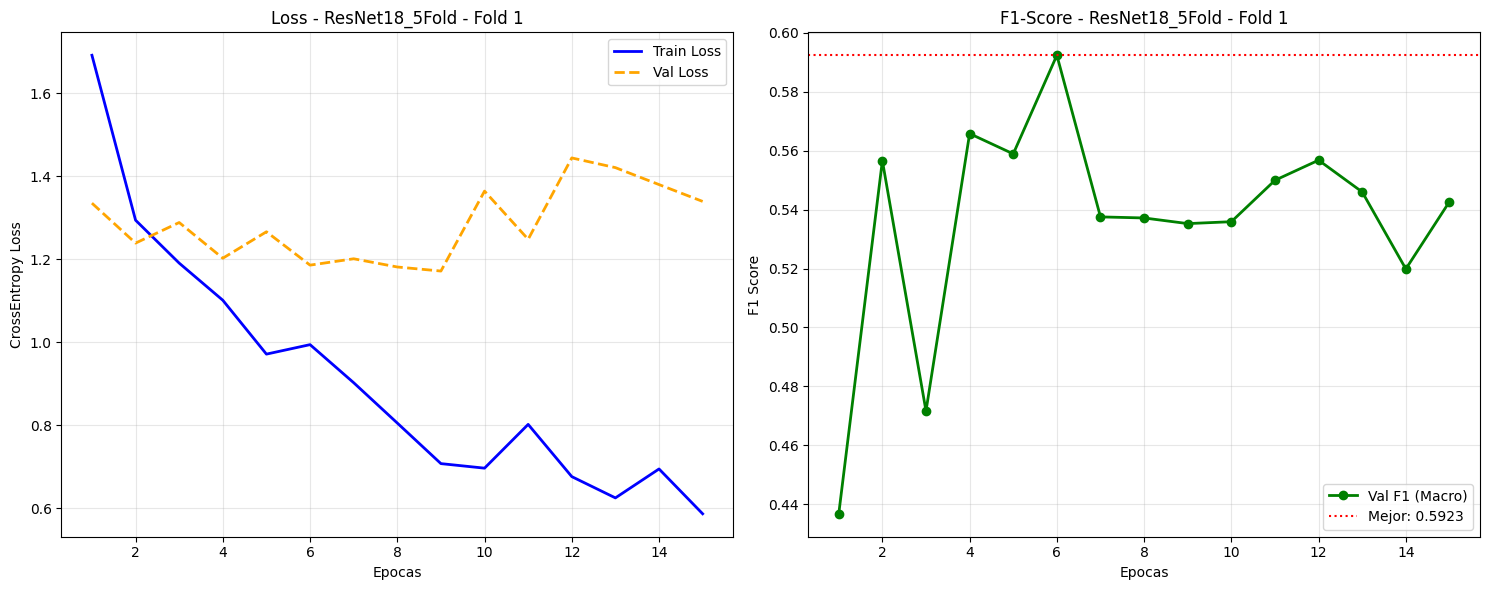

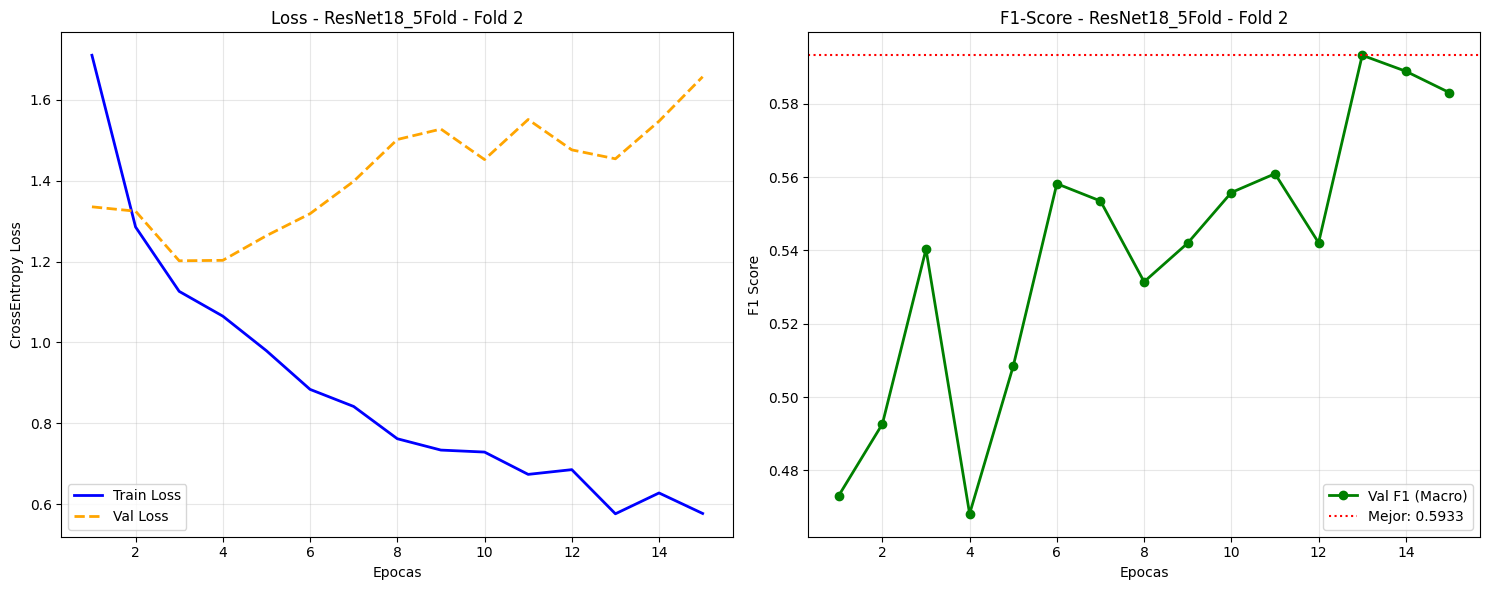

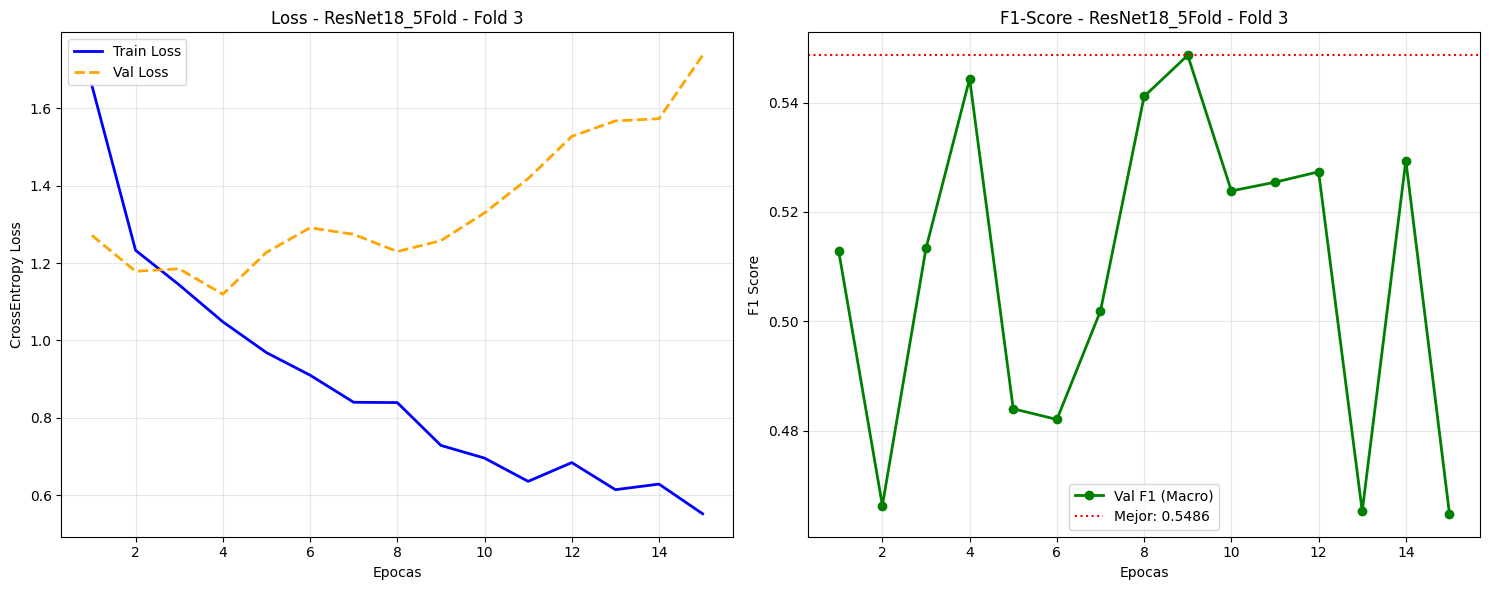

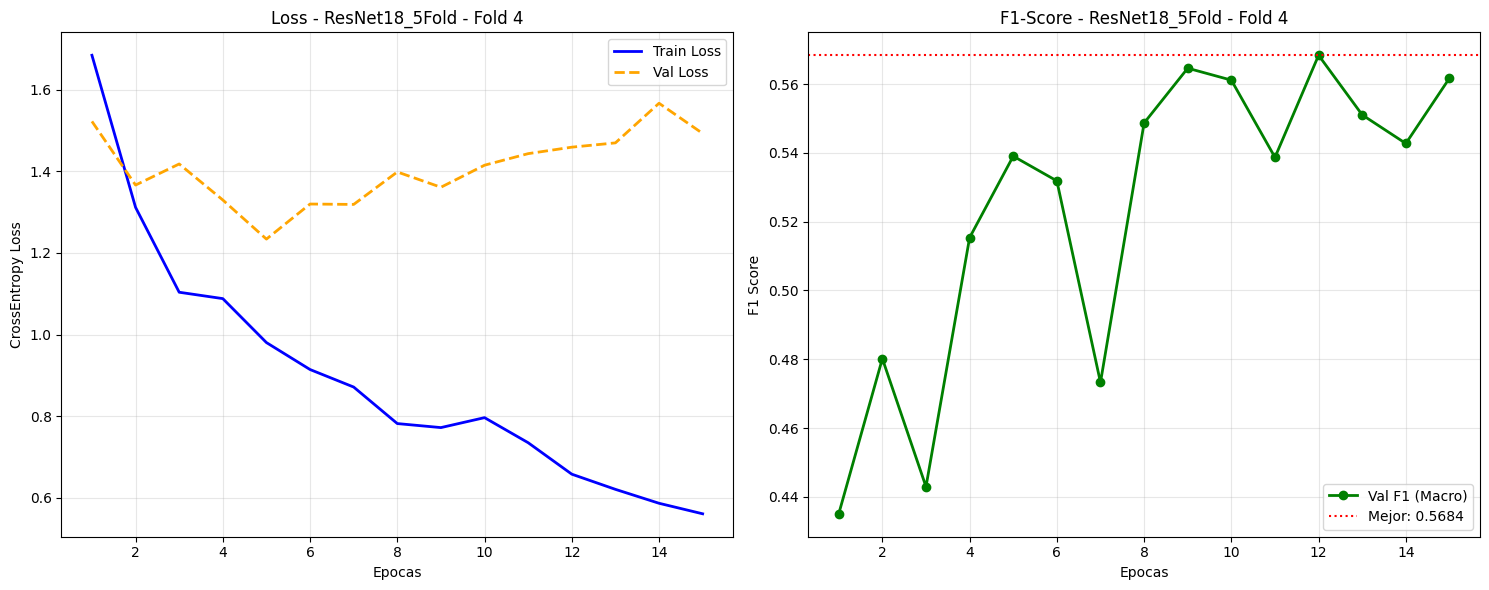

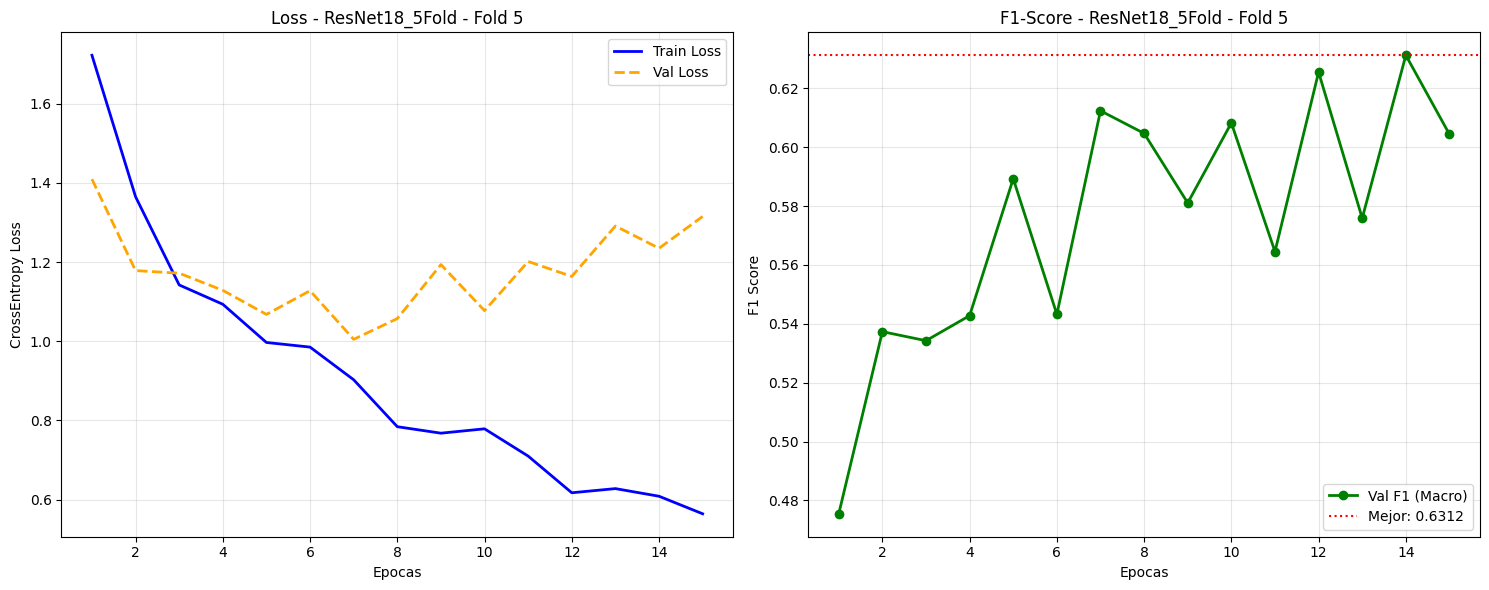


MATRICES DE CONFUSION POR FOLD (VALIDACION) - ResNet18_5Fold


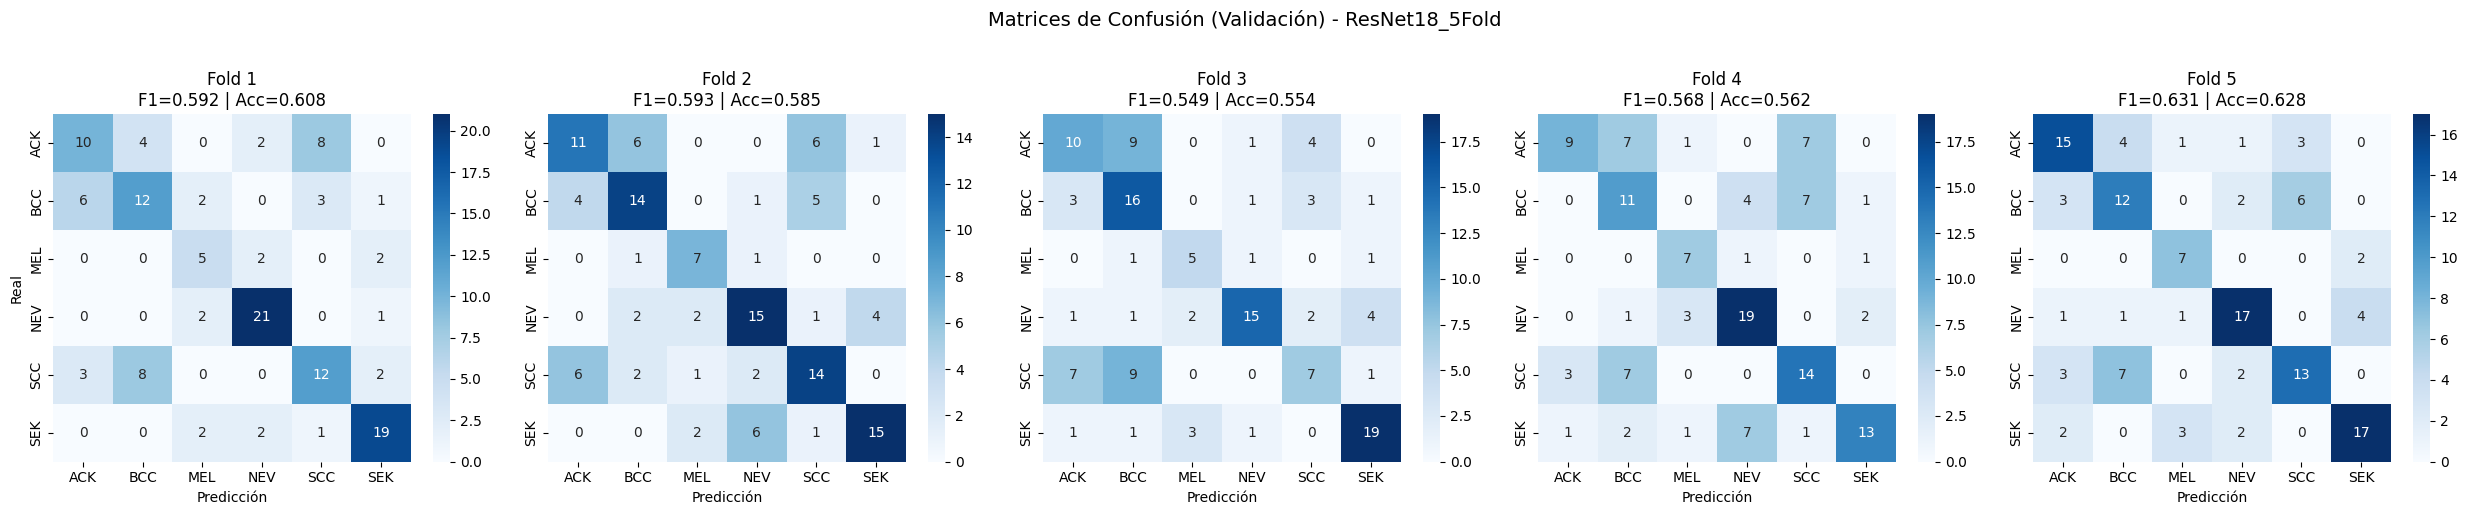


EVALUACION GLOBAL VALIDACION (todos los folds) - ResNet18_5Fold


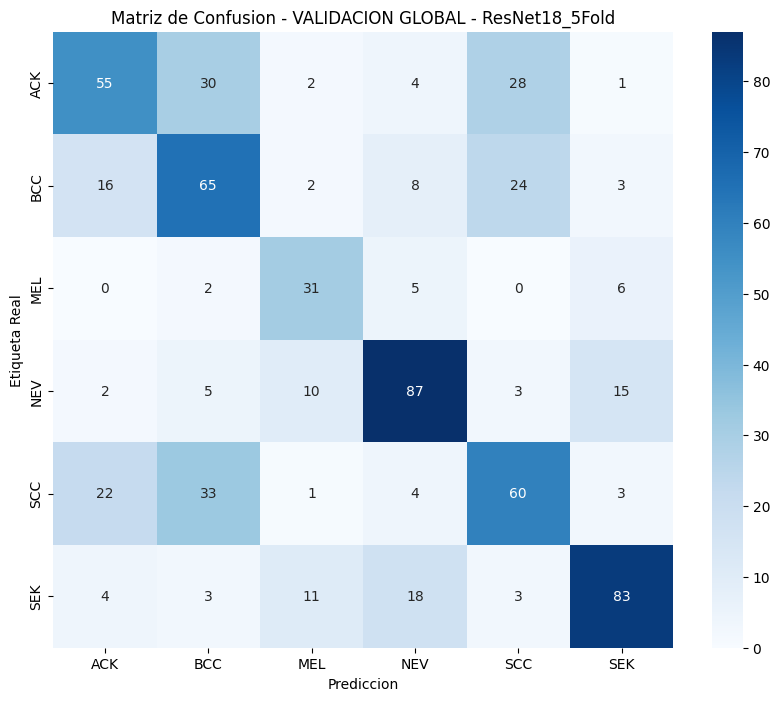


REPORTE: VALIDACION GLOBAL - ResNet18_5Fold
              precision    recall  f1-score   support

         ACK       0.56      0.46      0.50       120
         BCC       0.47      0.55      0.51       118
         MEL       0.54      0.70      0.61        44
         NEV       0.69      0.71      0.70       122
         SCC       0.51      0.49      0.50       123
         SEK       0.75      0.68      0.71       122

    accuracy                           0.59       649
   macro avg       0.59      0.60      0.59       649
weighted avg       0.59      0.59      0.59       649

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5871
  F1 Macro:           0.5893
  F1 Weighted:        0.5870
  Precision Macro:    0.5862
  Precision Weighted: 0.5920
  Recall Macro:       0.5992
  Recall Weighted:    0.5871
  Cohen's Kappa:      0.4989

ENSEMBLE 5 FOLDS - VALIDACION - ResNet18_5Fold
Nota: Cada muestra de validación solo fue vista por 1 modelo 

In [7]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


def crear_resnet18(num_classes, device):

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    num_ftrs = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, num_classes)
        )
    model = model.to(device)

    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': 0.000131},
        {'params': model.fc.parameters(), 'lr': 0.000437}
    ], weight_decay=0.02365)

    return model, optimizer


resultados_resnet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_resnet18,
    nombre_exp="ResNet18_5Fold",
    device=device,
    epochs=15
)


#### Resultados - ResNet18

**Métricas de Validación (5-Fold CV):**
- **F1-Macro**: 0.5868 ± 0.0277
- **Accuracy**: 0.5871 ± 0.0278
- **Cohen's Kappa**: 0.4989 ± 0.0340
- **Mejor Fold**: Fold 5 (F1=0.6312)

**Performance por clase (validación agregada):**
- ✅ **MEL**: 70% recall (31/44 detectados) - prioridad clínica cumplida
- ✅ **NEV**: 71%, **SEK**: 68% - clases benignas bien identificadas
- ⚠️ **ACK**: 46%, **SCC**: 49% - mayor confusión entre lesiones precancerosas
- ⚠️ **BCC**: 55%

**Confusiones principales:** ACK↔SCC, BCC↔SCC (difícil distinguir carcinomas entre sí)

**Nota:** El val loss aumenta mientras el F1 mejora. Esto ocurre porque CrossEntropy penaliza la confianza de las probabilidades, mientras que F1 solo mira si la predicción final es correcta.

### 6.2 DenseNet121

**Arquitectura:** 121 capas con conexiones densas. Cada capa recibe features de todas las anteriores, mejorando la reutilización.

**Transfer Learning:** Congelamos denseblocks 1-3, fine-tuning de denseblock4 + norm5 + clasificador.

**Hiperparámetros (Optuna):**

| Parámetro | Valor |
|-----------|-------|
| lr_backbone | 0.000960 |
| lr_head | 0.000218 |
| weight_decay | 0.000089 |
| dropout | 0.4 |
| batch_size | 16 |

Dropout más alto (0.4 vs 0.3) para compensar la mayor capacidad de DenseNet.

Usando device: cuda

EXPERIMENTO 5-FOLD CV: DenseNet121_5Fold

──────────────────────────────────────────────────
FOLD 1/5 | Train: 519 | Val: 130
──────────────────────────────────────────────────
  Ep 1/15 | Train Loss: 1.583 | Train F1: 0.3063 | Val Loss: 1.258 | Val F1: 0.5010 ** Mejor!
  Ep 2/15 | Train Loss: 1.217 | Train F1: 0.5234 | Val Loss: 1.217 | Val F1: 0.5123 ** Mejor!
  Ep 3/15 | Train Loss: 1.060 | Train F1: 0.5644 | Val Loss: 1.112 | Val F1: 0.5035
  Ep 4/15 | Train Loss: 0.972 | Train F1: 0.6351 | Val Loss: 1.157 | Val F1: 0.5316 ** Mejor!
  Ep 5/15 | Train Loss: 0.899 | Train F1: 0.6331 | Val Loss: 1.117 | Val F1: 0.5951 ** Mejor!
  Ep 6/15 | Train Loss: 0.824 | Train F1: 0.6534 | Val Loss: 1.078 | Val F1: 0.6087 ** Mejor!
  Ep 7/15 | Train Loss: 0.787 | Train F1: 0.7045 | Val Loss: 1.157 | Val F1: 0.5312
  Ep 8/15 | Train Loss: 0.758 | Train F1: 0.6935 | Val Loss: 1.146 | Val F1: 0.6290 ** Mejor!
  Ep 9/15 | Train Loss: 0.792 | Train F1: 0.6979 | Val Loss: 1.137 | V

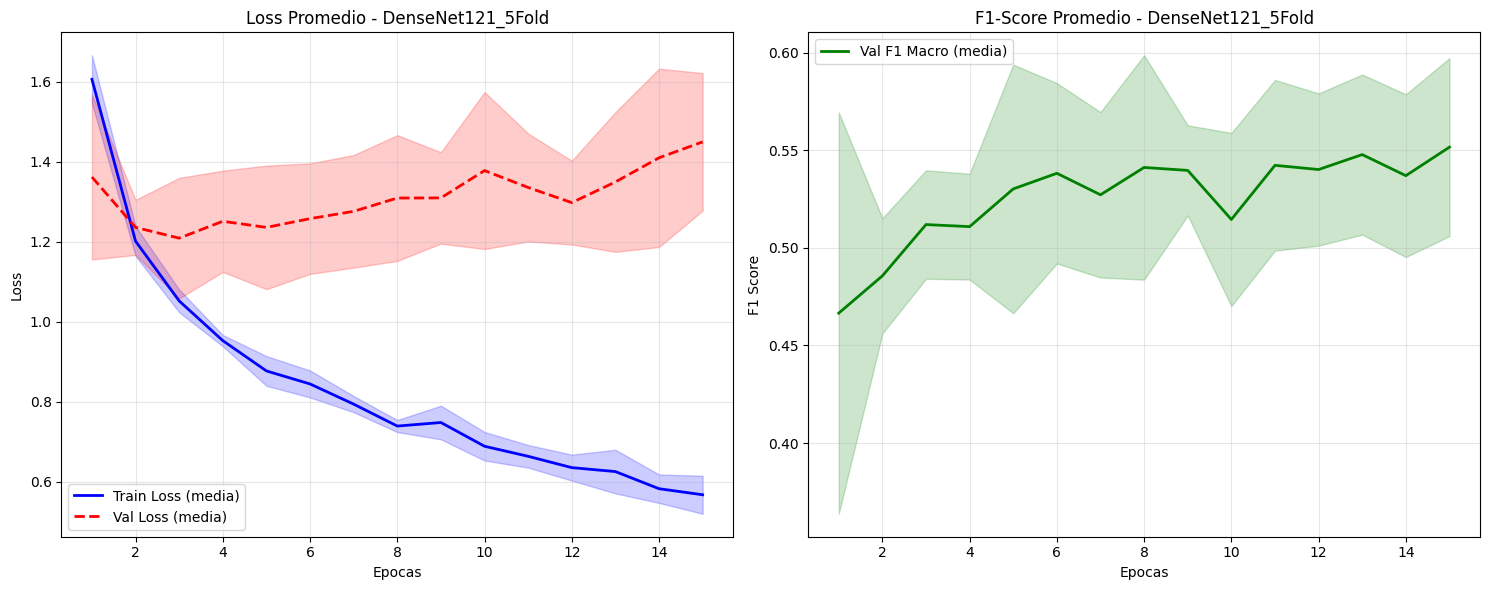

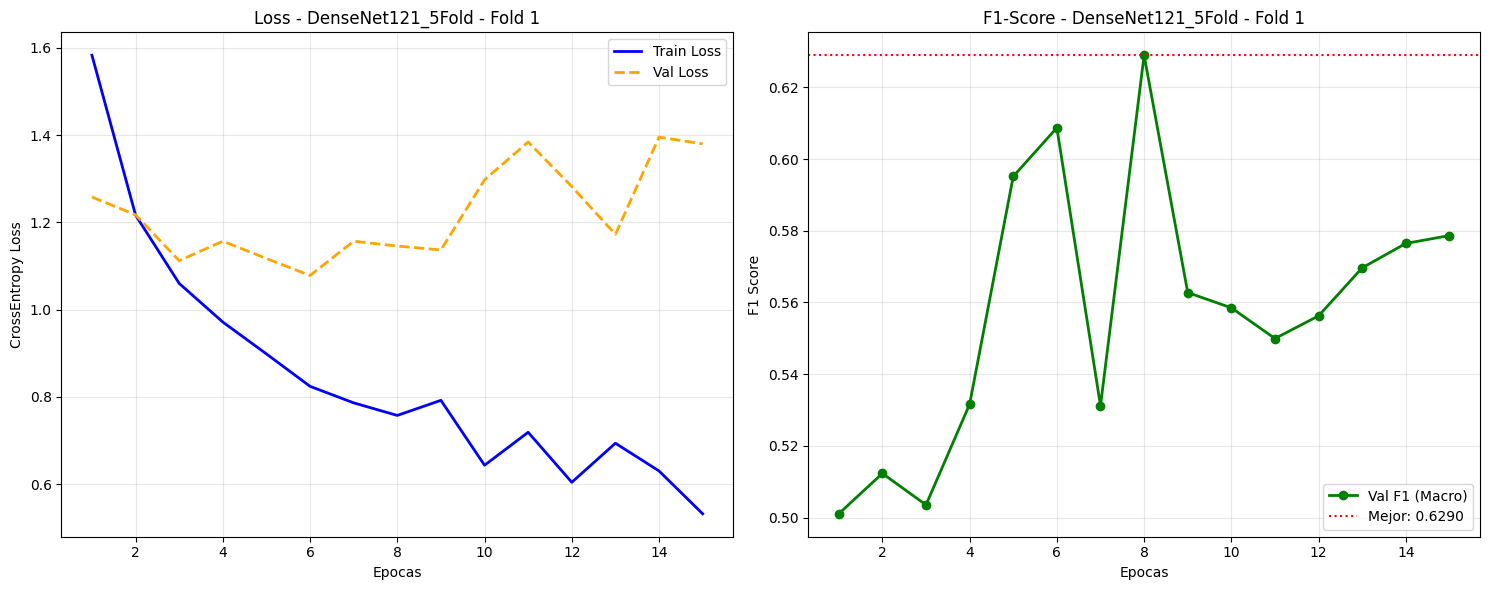

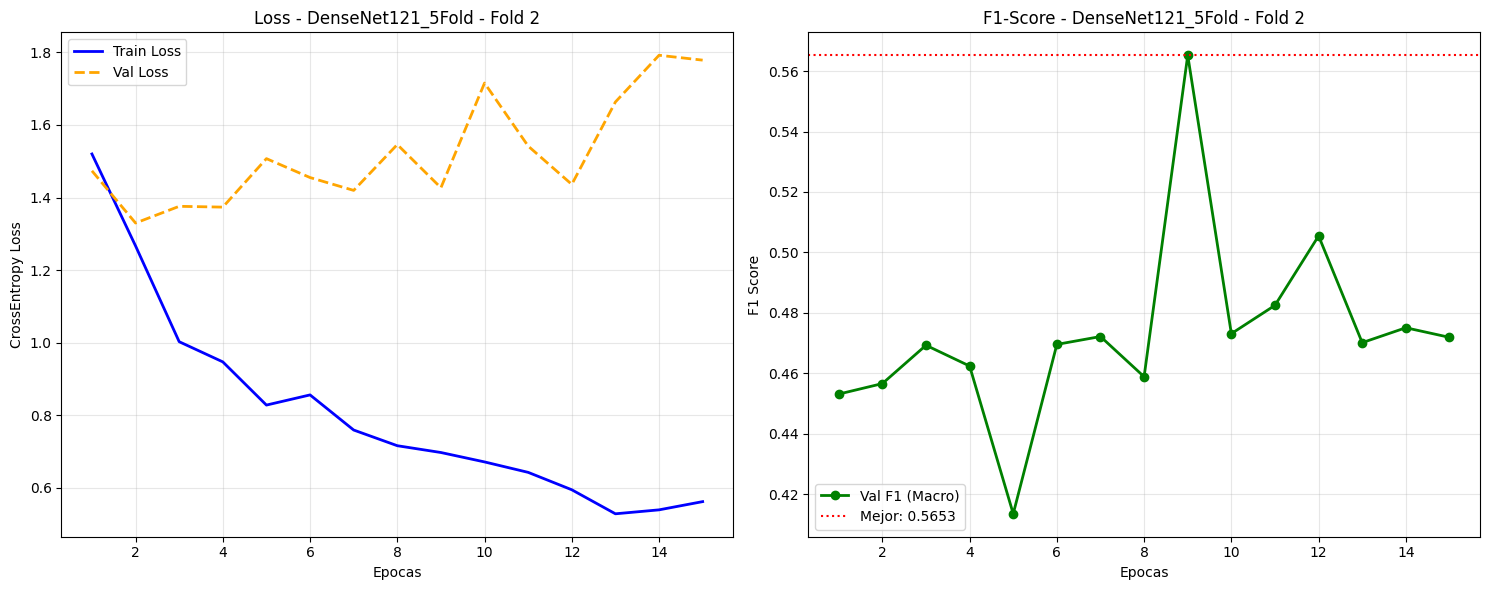

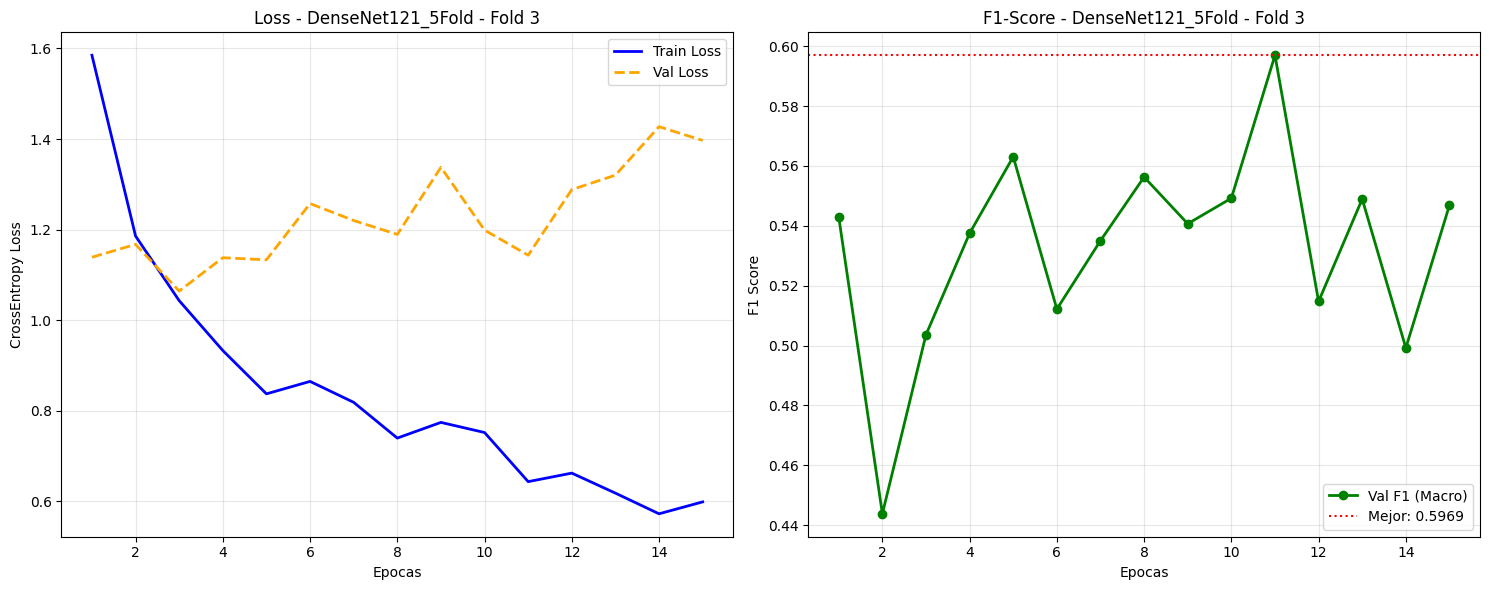

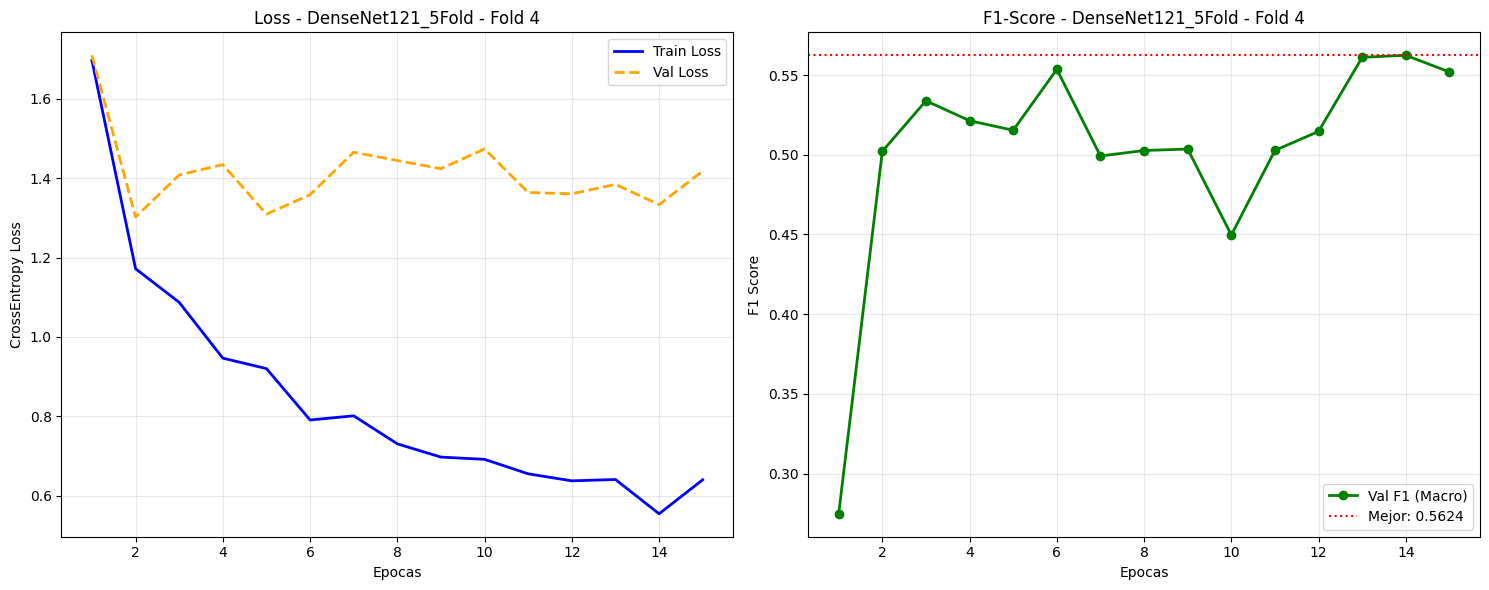

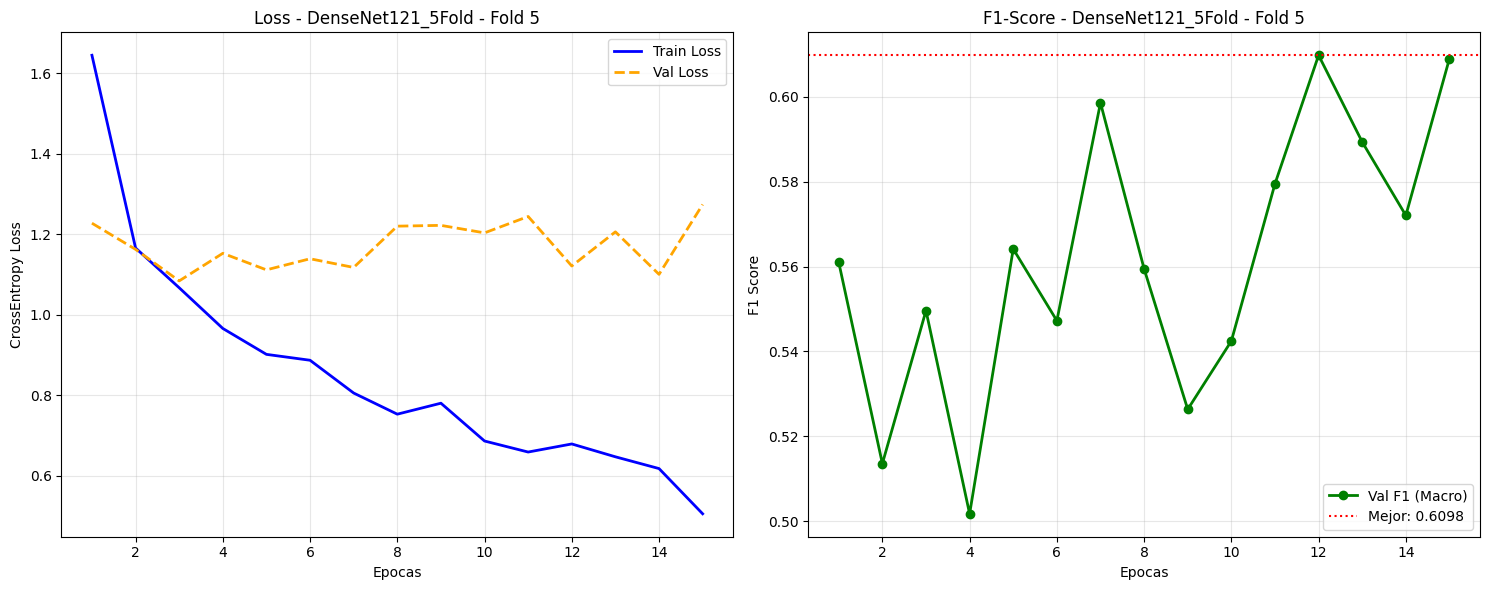


MATRICES DE CONFUSION POR FOLD (VALIDACION) - DenseNet121_5Fold


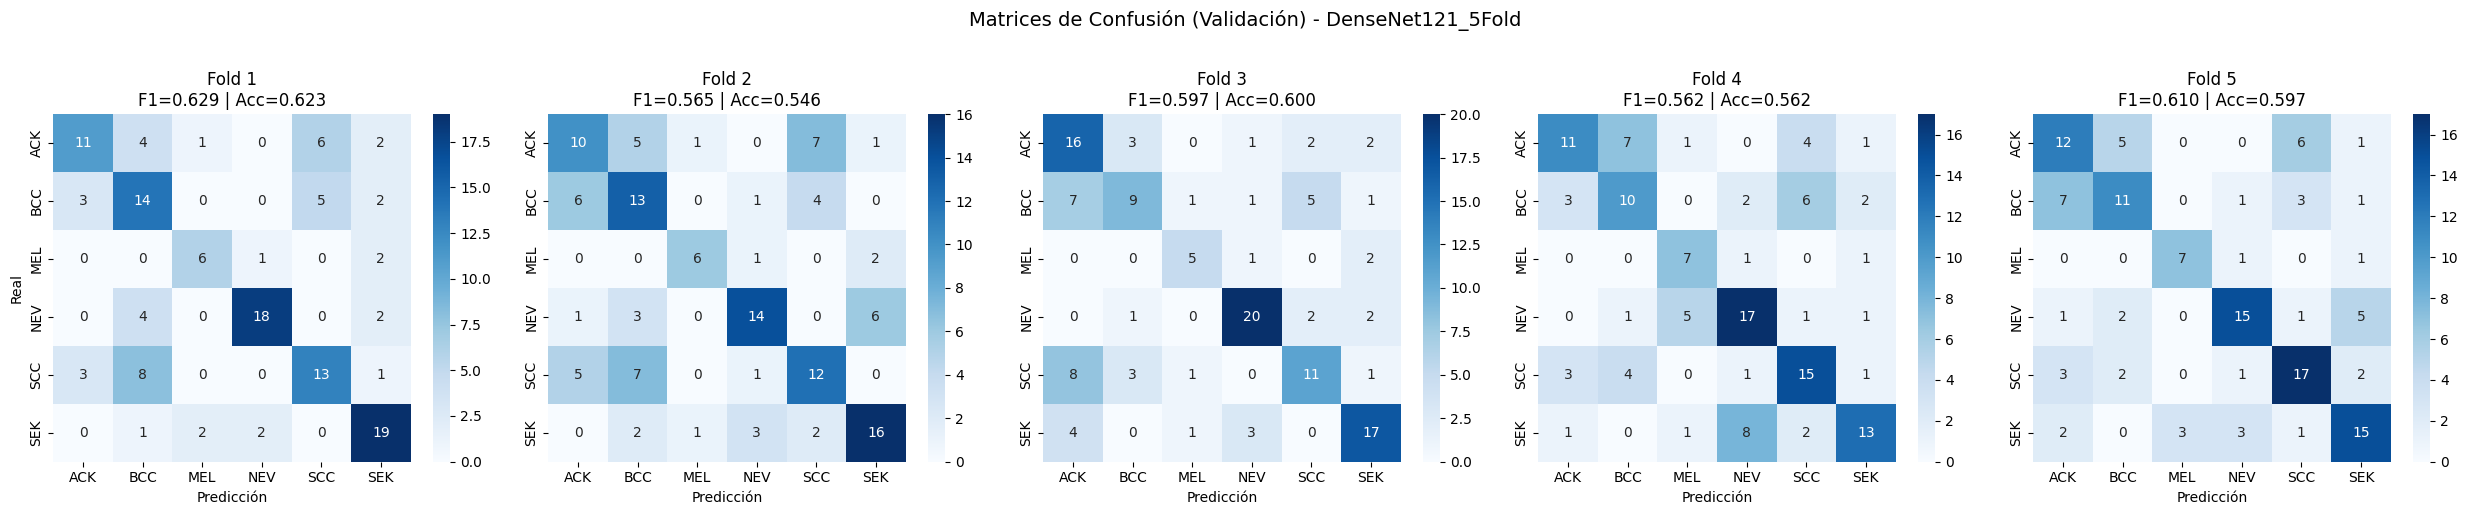


EVALUACION GLOBAL VALIDACION (todos los folds) - DenseNet121_5Fold


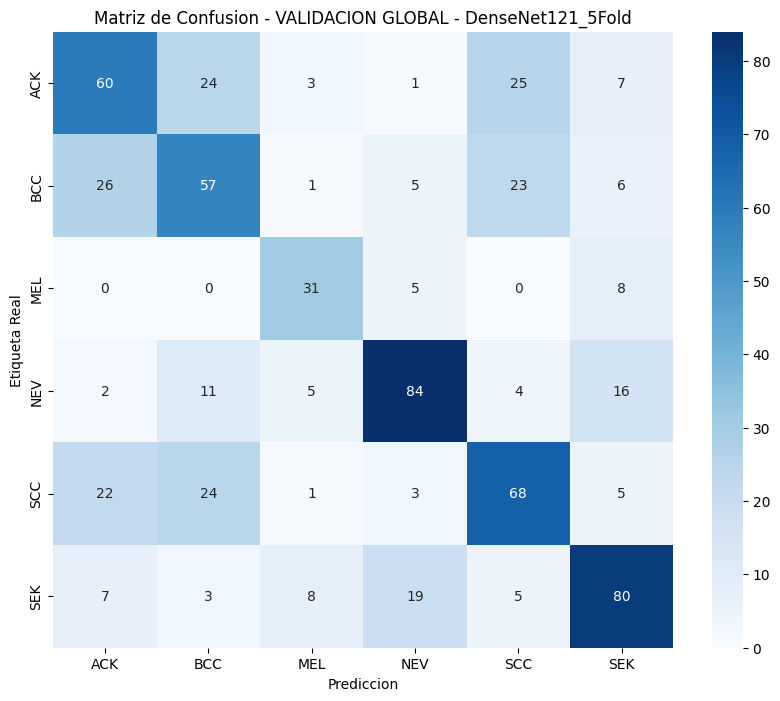


REPORTE: VALIDACION GLOBAL - DenseNet121_5Fold
              precision    recall  f1-score   support

         ACK       0.51      0.50      0.51       120
         BCC       0.48      0.48      0.48       118
         MEL       0.63      0.70      0.67        44
         NEV       0.72      0.69      0.70       122
         SCC       0.54      0.55      0.55       123
         SEK       0.66      0.66      0.66       122

    accuracy                           0.59       649
   macro avg       0.59      0.60      0.59       649
weighted avg       0.59      0.59      0.59       649

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5855
  F1 Macro:           0.5935
  F1 Weighted:        0.5856
  Precision Macro:    0.5904
  Precision Weighted: 0.5861
  Recall Macro:       0.5975
  Recall Weighted:    0.5855
  Cohen's Kappa:      0.4961

ENSEMBLE 5 FOLDS - VALIDACION - DenseNet121_5Fold
Nota: Cada muestra de validación solo fue vista por 1 m

In [8]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


def crear_densenet121(num_classes, device):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
    for param in model.features.norm5.parameters():
        param.requires_grad = True

    num_ftrs = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_ftrs, num_classes)
        )

    model = model.to(device)
    optimizer = optim.AdamW([
        {'params': model.features.denseblock4.parameters(), 'lr': 0.000960},
        {'params': model.features.norm5.parameters(), 'lr': 0.000960},
        {'params': model.classifier.parameters(), 'lr': 0.000218}
    ], weight_decay=0.000089)
    return model, optimizer


resultados_densenet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_densenet121,
    nombre_exp="DenseNet121_5Fold",
    device=device,
    epochs=15
)


#### Resultados - DenseNet121

**Métricas de Validación (5-Fold CV):**
- **F1-Macro**: 0.5927 ± 0.0257
- **Accuracy**: 0.5855 ± 0.0278
- **Cohen's Kappa**: 0.4960 ± 0.0335
- **Mejor Fold**: Fold 1 (F1=0.6290)

**Performance por clase:**
- ✅ **MEL**: 70% recall - igual que ResNet
- ✅ **SCC**: 55% - mejora vs ResNet (49%)
- ✅ **ACK**: 50% - mejora vs ResNet (46%)
- ⚠️ **BCC**: 48% - peor que ResNet (55%)

**Comparación con ResNet:**
- DenseNet: F1=0.5927 vs ResNet: F1=0.5868 (+1% mejora)
- Ambos logran 70% recall en MEL
- DenseNet tiene menor variabilidad entre folds (std=0.026 vs 0.028)

### 6.3 YOLO26x

**Arquitectura:** YOLO está diseñado para detección de objetos, pero usamos su variante de clasificación. A diferencia de ResNet/DenseNet, hacemos fine-tuning completo (sin congelar capas).

**Particularidad:** YOLO requiere estructura de carpetas específica. Creamos symlinks para cada fold sin duplicar imágenes.

**Hiperparámetros (Optuna):**

| Parámetro | Valor |
|-----------|-------|
| lr0 | 0.009336 |
| lrf | 0.036616 |
| momentum | 0.893299 |
| dropout | 0.4 |
| optimizer | SGD |

YOLO usa LR inicial más alto con warmup (primeras 4 épocas) y scheduler coseno.

In [9]:
import os
import shutil

# Ruta donde se crearan las carpetas de cada fold
FOLDS_DIR = os.path.abspath(os.path.join(RUTA_BASE, "folds"))
classes = full_train_dataset.classes

# Limpiar folds anteriores si existen
if os.path.exists(FOLDS_DIR):
    shutil.rmtree(FOLDS_DIR)

for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
    fold_name = f"fold_{fold+1}"

    # Crear carpetas train/val por clase
    for split_name in ["train", "val"]:
        for class_name in classes:
            os.makedirs(os.path.join(FOLDS_DIR, fold_name, split_name, class_name), exist_ok=True)

    # Symlinks para train del fold
    for idx in train_idx:
        src = os.path.abspath(full_train_dataset.samples[idx][0])
        cls = classes[full_train_dataset.targets[idx]]
        dst = os.path.join(FOLDS_DIR, fold_name, "train", cls, os.path.basename(src))
        os.symlink(src, dst)

    # Symlinks para val del fold
    for idx in val_idx:
        src = os.path.abspath(full_train_dataset.samples[idx][0])
        cls = classes[full_train_dataset.targets[idx]]
        dst = os.path.join(FOLDS_DIR, fold_name, "val", cls, os.path.basename(src))
        os.symlink(src, dst)

    print(f"Fold {fold+1}: train={len(train_idx)} imgs, val={len(val_idx)} imgs")

print(f"\nEstructura creada en: {FOLDS_DIR}")

# Verificar conteos
for fold in range(1, K_FOLDS + 1):
    print(f"\n--- Fold {fold} ---")
    for split_name in ["train", "val"]:
        total = 0
        for class_name in classes:
            path = os.path.join(FOLDS_DIR, f"fold_{fold}", split_name, class_name)
            n = len(os.listdir(path))
            total += n
        print(f"  {split_name}: {total} imgs")

Fold 1: train=519 imgs, val=130 imgs
Fold 2: train=519 imgs, val=130 imgs
Fold 3: train=519 imgs, val=130 imgs
Fold 4: train=519 imgs, val=130 imgs
Fold 5: train=520 imgs, val=129 imgs

Estructura creada en: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds

--- Fold 1 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 2 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 3 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 4 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 5 ---
  train: 520 imgs
  val: 129 imgs


In [10]:
from ultralytics import YOLO
import torch
import gc

mejores_pesos_yolo = []

# Hiperparámetros óptimos encontrados por Optuna
BEST_PARAMS = {
    'lr0': 0.009336,
    'lrf': 0.036616,
    'momentum': 0.893299,
    'weight_decay': 0.000569,
    'warmup_epochs': 4,
    'dropout': 0.4,
    'batch': 16,
    'optimizer': 'SGD'
}

for fold in range(1, K_FOLDS + 1):
    fold_path = os.path.abspath(os.path.join(FOLDS_DIR, f"fold_{fold}"))

    print(f"\n{'='*50}")
    print(f"YOLO26x - FOLD {fold}/{K_FOLDS}")
    print(f"Data: {fold_path}")
    print(f"{'='*50}")

    model = YOLO('yolo26x-cls.pt')

    results = model.train(
        data=fold_path,
        epochs=25,
        imgsz=224,
        batch=BEST_PARAMS['batch'],
        patience=5,
        project='runs',
        name=f'YOLO26x_Fold{fold}',
        # Hiperparámetros óptimos de Optuna
        lr0=BEST_PARAMS['lr0'],
        lrf=BEST_PARAMS['lrf'],
        momentum=BEST_PARAMS['momentum'],
        weight_decay=BEST_PARAMS['weight_decay'],
        warmup_epochs=BEST_PARAMS['warmup_epochs'],
        dropout=BEST_PARAMS['dropout'],
        optimizer=BEST_PARAMS['optimizer']
    )

    # Guardar ruta del mejor modelo de este fold
    best_pt = f"runs/YOLO26x_Fold{fold}/weights/best.pt"
    mejores_pesos_yolo.append(best_pt)
    print(f"✅ Fold {fold} completado. Pesos: {best_pt}")
    
    # ⚠️ CRÍTICO: Liberar memoria entre folds
    del model
    del results
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    
    gc.collect()
    print(f"🧹 Memoria liberada después del fold {fold}")

print(f"\n{'='*50}")
print("✅ 5-Fold YOLO completado.")
print(f"{'='*50}")
for i, p in enumerate(mejores_pesos_yolo):
    print(f"  Fold {i+1}: {p}")


YOLO26x - FOLD 1/5
Data: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1
New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.4, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7595.1±3406.5 MB/s, size: 3744.0 KB)
train: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/train... 519 images, 0 corrupt: 100% ━━━━━━━━━━━━ 519/519 280.3it/s 1.9s0.1s
train: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1136.0±95.7 MB/s, size: 408.7 KB)
val: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/val... 130 images, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 193.2it/s 0.7s0.1s
val: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/val.cache
optimizer: SGD(lr=0.009336, 

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       1/25      2.01G      1.933         16        224: 0% ──────────── 0/33  2.5s

...

      19/25      2.65G     0.3876          8        224: 100% ━━━━━━━━━━━━ 33/33 8.8it/s 3.7s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 16.7it/s 0.3s.1s
                   all      0.636      0.992

      Epoch    GPU_mem       loss  Instances       Size
      20/25      2.65G     0.4788         16        224: 0% ──────────── 0/33  0.2s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      20/25      2.65G     0.2987          8        224: 100% ━━━━━━━━━━━━ 33/33 8.6it/s 3.8s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 17.5it/s 0.3s.1s
                   all      0.612      0.984

      Epoch    GPU_mem       loss  Instances       Size
      21/25      2.65G     0.2516         16        224: 0% ──────────── 0/33  0.1s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      21/25      2.65G     0.3807          8        224: 100% ━━━━━━━━━━━━ 33/33 5.3it/s 6.3s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 17.1it/s 0.3s.1s
                   all      0.612      0.984
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 16, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

21 epochs completed in 0.030 hours.
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final/runs/classify/runs/YOLO26x_Fold5/weights/last.pt, 57.0MB
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final/runs/classify/runs/YOLO26x_Fold5/weights/best.pt, 57.0MB

Validating /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-proje

#### Evaluación de YOLO (Validación 5-Fold)

YOLO se entrena con su CLI de Ultralytics. Este código solo evalúa los modelos ya entrenados, cargando los `best.pt` de cada fold y calculando métricas comparables con ResNet/DenseNet.


EVALUACION 5-FOLD CV (VALIDACION): YOLO26x_5Fold

──────────────────────────────────────────────────
FOLD 1/5
──────────────────────────────────────────────────
  >> Fold 1 Val: F1=0.5861 | Acc=0.6077 | Kappa=0.5199

──────────────────────────────────────────────────
FOLD 2/5
──────────────────────────────────────────────────
  >> Fold 2 Val: F1=0.5001 | Acc=0.5231 | Kappa=0.4188

──────────────────────────────────────────────────
FOLD 3/5
──────────────────────────────────────────────────
  >> Fold 3 Val: F1=0.6263 | Acc=0.6692 | Kappa=0.5936

──────────────────────────────────────────────────
FOLD 4/5
──────────────────────────────────────────────────
  >> Fold 4 Val: F1=0.5850 | Acc=0.5769 | Kappa=0.4827

──────────────────────────────────────────────────
FOLD 5/5
──────────────────────────────────────────────────
  >> Fold 5 Val: F1=0.6381 | Acc=0.6434 | Kappa=0.5664

RESUMEN 5-FOLD CV: YOLO26x_5Fold
                    Fold 1  Fold 2  Fold 3  Fold 4  Fold 5   Media     Std
f1_mac

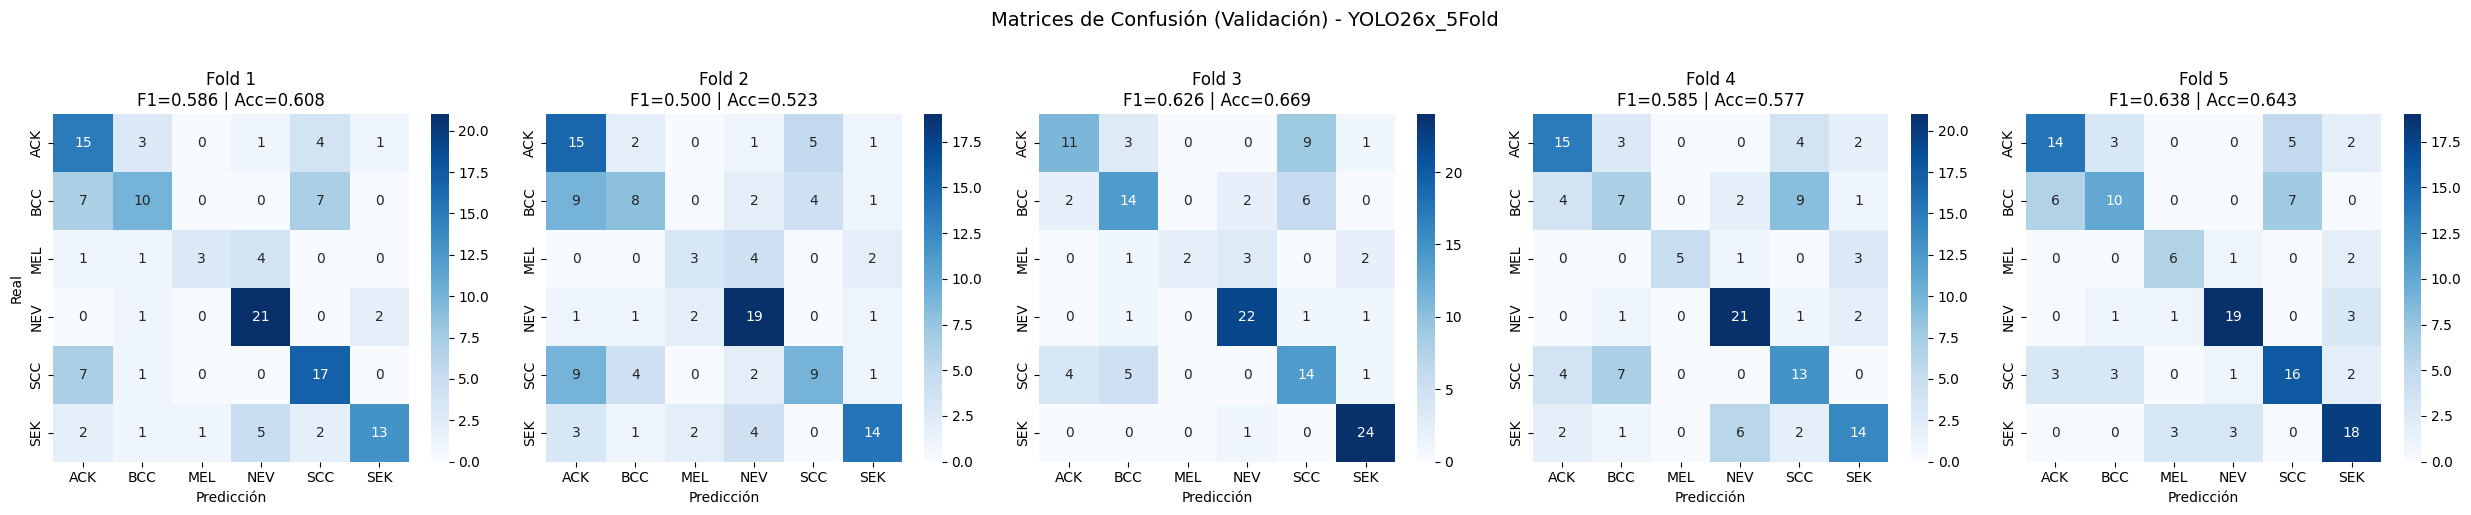


EVALUACION GLOBAL VALIDACION (todos los folds) - YOLO26x_5Fold


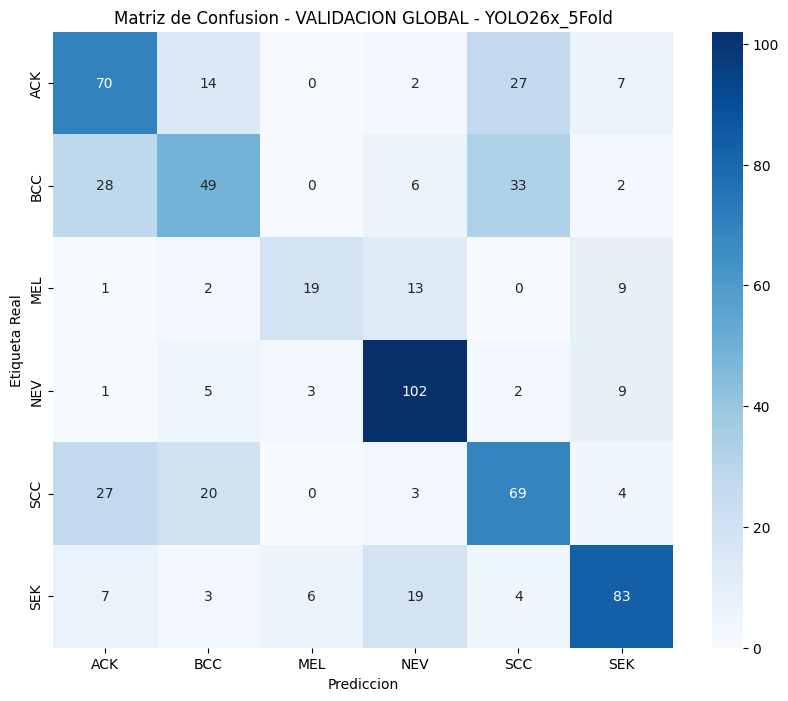


REPORTE: VALIDACION GLOBAL - YOLO26x_5Fold
              precision    recall  f1-score   support

         ACK       0.52      0.58      0.55       120
         BCC       0.53      0.42      0.46       118
         MEL       0.68      0.43      0.53        44
         NEV       0.70      0.84      0.76       122
         SCC       0.51      0.56      0.53       123
         SEK       0.73      0.68      0.70       122

    accuracy                           0.60       649
   macro avg       0.61      0.58      0.59       649
weighted avg       0.60      0.60      0.60       649

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6040
  F1 Macro:           0.5910
  F1 Weighted:        0.5994
  Precision Macro:    0.6117
  Precision Weighted: 0.6044
  Recall Macro:       0.5846
  Recall Weighted:    0.6040
  Cohen's Kappa:      0.5161

MEJOR FOLD YOLO: 5 (F1 Macro Val = 0.6381)


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# FUNCION: obtener predicciones de un modelo YOLO sobre una carpeta
# ============================================================

def obtener_predicciones_yolo(model, carpeta, classes):
    """Evalua un modelo YOLO imagen por imagen sobre una carpeta con subcarpetas por clase.

    Returns: y_true, y_pred, y_probs (arrays numpy alineados con el orden de 'classes')
    """
    name_to_idx = {c: i for i, c in enumerate(classes)}
    y_true, y_pred, y_probs = [], [], []

    for cls_name in classes:
        cls_path = os.path.join(carpeta, cls_name)
        if not os.path.isdir(cls_path):
            continue
        true_idx = name_to_idx[cls_name]

        files = sorted([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        for file in files:
            img_path = os.path.join(cls_path, file)
            results = model(img_path, verbose=False)

            # Alinear probabilidades YOLO con nuestro orden de clases
            probs = np.zeros(len(classes))
            raw_probs = results[0].probs.data.cpu().numpy()
            for yolo_idx, conf in enumerate(raw_probs):
                yolo_name = results[0].names[yolo_idx]
                if yolo_name in name_to_idx:
                    probs[name_to_idx[yolo_name]] = conf

            y_true.append(true_idx)
            y_pred.append(np.argmax(probs))
            y_probs.append(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_probs)


# ============================================================
# EVALUACION 5-FOLD YOLO (SIN TEST - solo validación)
# ============================================================

nombre_exp = "YOLO26x_5Fold"
classes = full_train_dataset.classes
num_classes = len(classes)

# Rutas reales de los pesos (YOLO guarda en runs/classify/runs/)
pesos_yolo = [f"runs/classify/runs/YOLO26x_Fold{f}/weights/best.pt" for f in range(1, K_FOLDS + 1)]

print(f"\n{'='*60}")
print(f"EVALUACION 5-FOLD CV (VALIDACION): {nombre_exp}")
print(f"{'='*60}")

metricas_folds_yolo = []
predicciones_val_por_fold_yolo = []
y_true_val_todos_yolo = []
y_pred_val_todos_yolo = []
y_probs_val_todos_yolo = []

for fold in range(1, K_FOLDS + 1):
    print(f"\n{'─'*50}")
    print(f"FOLD {fold}/{K_FOLDS}")
    print(f"{'─'*50}")

    model_yolo = YOLO(pesos_yolo[fold - 1])

    # --- Evaluacion en VALIDACION del fold ---
    carpeta_val = os.path.abspath(os.path.join(FOLDS_DIR, f"fold_{fold}", "val"))
    y_true_val, y_pred_val, y_probs_val = obtener_predicciones_yolo(model_yolo, carpeta_val, classes)
    fold_metricas = calcular_metricas(y_true_val, y_pred_val)

    print(f"  >> Fold {fold} Val: F1={fold_metricas['f1_macro']:.4f} | "
          f"Acc={fold_metricas['accuracy']:.4f} | Kappa={fold_metricas['kappa']:.4f}")

    metricas_folds_yolo.append(fold_metricas)
    predicciones_val_por_fold_yolo.append((y_true_val, y_pred_val))

    # Acumular para evaluación global
    y_true_val_todos_yolo.extend(y_true_val)
    y_pred_val_todos_yolo.extend(y_pred_val)
    y_probs_val_todos_yolo.extend(y_probs_val)

# ============================================================
# RESUMEN CROSS-VALIDATION YOLO
# ============================================================
print(f"\n{'='*60}")
print(f"RESUMEN 5-FOLD CV: {nombre_exp}")
print(f"{'='*60}")

metric_names = ['f1_macro', 'f1_weighted', 'accuracy',
                'precision_macro', 'precision_weighted',
                'recall_macro', 'recall_weighted', 'kappa']

tabla = {}
for metric in metric_names:
    valores = [m[metric] for m in metricas_folds_yolo]
    tabla[metric] = [round(v, 4) for v in valores] + [round(np.mean(valores), 4), round(np.std(valores), 4)]

cols = [f"Fold {i+1}" for i in range(K_FOLDS)] + ["Media", "Std"]
df_resumen_yolo = pd.DataFrame(tabla, index=cols).T
print(df_resumen_yolo.to_string())

# ============================================================
# MATRICES DE CONFUSION POR FOLD (VALIDACION) - YOLO
# ============================================================
print(f"\n{'='*60}")
print(f"MATRICES DE CONFUSION POR FOLD (VALIDACION) - {nombre_exp}")
print(f"{'='*60}")

mostrar_matrices_confusion_folds(predicciones_val_por_fold_yolo, classes, nombre_exp)

# ============================================================
# EVALUACION GLOBAL EN VALIDACION - YOLO
# ============================================================
print(f"\n{'='*60}")
print(f"EVALUACION GLOBAL VALIDACION (todos los folds) - {nombre_exp}")
print(f"{'='*60}")

y_true_val_todos_yolo = np.array(y_true_val_todos_yolo)
y_pred_val_todos_yolo = np.array(y_pred_val_todos_yolo)

metricas_val_global_yolo = mostrar_reporte_completo(
    y_true_val_todos_yolo, y_pred_val_todos_yolo, classes,
    f"VALIDACION GLOBAL - {nombre_exp}"
)

# ============================================================
# MEJOR FOLD YOLO
# ============================================================
f1_scores_yolo = [m['f1_macro'] for m in metricas_folds_yolo]
best_fold_yolo = int(np.argmax(f1_scores_yolo))

print(f"\n{'='*60}")
print(f"MEJOR FOLD YOLO: {best_fold_yolo+1} (F1 Macro Val = {f1_scores_yolo[best_fold_yolo]:.4f})")
print(f"{'='*60}")

# Guardar resultados para uso posterior
resultados_yolo = {
    'metricas_folds': metricas_folds_yolo,
    'predicciones_val_por_fold': predicciones_val_por_fold_yolo,
    'best_fold': best_fold_yolo,
    'df_resumen': df_resumen_yolo,
    'metricas_val_global': metricas_val_global_yolo,
    'pesos': pesos_yolo,
}


#### Resultados - YOLO26x

**Métricas de Validación (5-Fold CV):**
- **F1-Macro**: 0.5871 ± 0.0484
- **Accuracy**: 0.6041 ± 0.0512
- **Cohen's Kappa**: 0.5163 ± 0.0619
- **Mejor Fold**: Fold 5 (F1=0.6381)

**Performance por clase:**
- ✅ **NEV**: **84% recall** - el mejor de todos los modelos
- ✅ **SEK**: 68%, **ACK**: 58%
- ⚠️ **MEL**: **43% recall** - solo detecta 19/44 melanomas
- ⚠️ **BCC**: 42% - el peor

**Problema crítico:** YOLO sacrifica la detección de MEL para mejorar en clases benignas. Tiene el peor recall de melanoma (43% vs 70% de ResNet/DenseNet).

**Confusiones graves:** MEL→NEV (13 casos), MEL→SEK (9 casos). Muchos melanomas clasificados como benignos.

| Modelo | F1-Macro | MEL Recall | Variabilidad |
|--------|----------|------------|--------------|
| ResNet18 | 0.5868 | **70%** ✅ | std=0.028 |
| DenseNet121 | 0.5927 | **70%** ✅ | std=0.026 |
| YOLO26x | 0.5871 | **43%** ❌ | std=0.048 |

**Conclusión:** YOLO no es adecuado para este problema clínico. Aunque tiene F1 similar, falla en la clase más importante.

## 7. Comparación por AUC-ROC (One-vs-All)

**¿Por qué AUC?**
- F1 usa argmax (umbral fijo 0.5)
- AUC evalúa la capacidad de discriminación en todos los umbrales
- Un modelo puede tener buen AUC pero mal F1 si su umbral óptimo no es 0.5

**Metodología:**
1. Calcular AUC-Macro por fold para cada modelo
2. Seleccionar el mejor fold según AUC
3. Comparar curvas ROC por clase

Esto nos ayuda a elegir qué fold de cada modelo usar en el ensemble.

COMPARATIVA AUC ROC ONE-VS-ALL - 5 FOLDS (VALIDACIÓN)

>>> Evaluando ResNet 5 folds en validación...
  Fold 1: AUC_macro=0.8644, F1_macro=0.5923
  Fold 2: AUC_macro=0.8566, F1_macro=0.5933
  Fold 3: AUC_macro=0.8653, F1_macro=0.5486
  Fold 4: AUC_macro=0.8536, F1_macro=0.5684
  Fold 5: AUC_macro=0.8792, F1_macro=0.6312

>>> Evaluando DenseNet 5 folds en validación...
  Fold 1: AUC_macro=0.8775, F1_macro=0.6290
  Fold 2: AUC_macro=0.8281, F1_macro=0.5653
  Fold 3: AUC_macro=0.8825, F1_macro=0.5969
  Fold 4: AUC_macro=0.8650, F1_macro=0.5624
  Fold 5: AUC_macro=0.8871, F1_macro=0.6098

>>> Evaluando YOLO 5 folds en validación...
  Fold 1: AUC_macro=0.8598, F1_macro=0.5861
  Fold 2: AUC_macro=0.8565, F1_macro=0.5001
  Fold 3: AUC_macro=0.9131, F1_macro=0.6263
  Fold 4: AUC_macro=0.8413, F1_macro=0.5850
  Fold 5: AUC_macro=0.9121, F1_macro=0.6381


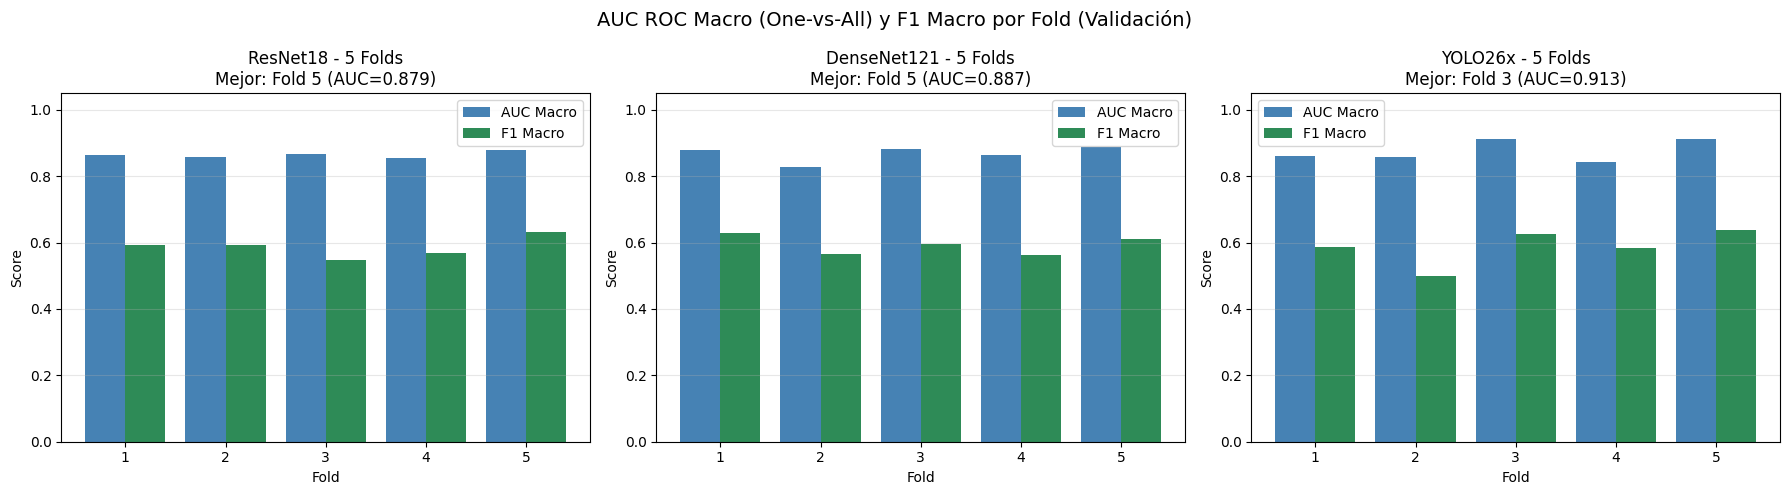


CURVAS ROC POR CLASE - MEJORES FOLDS


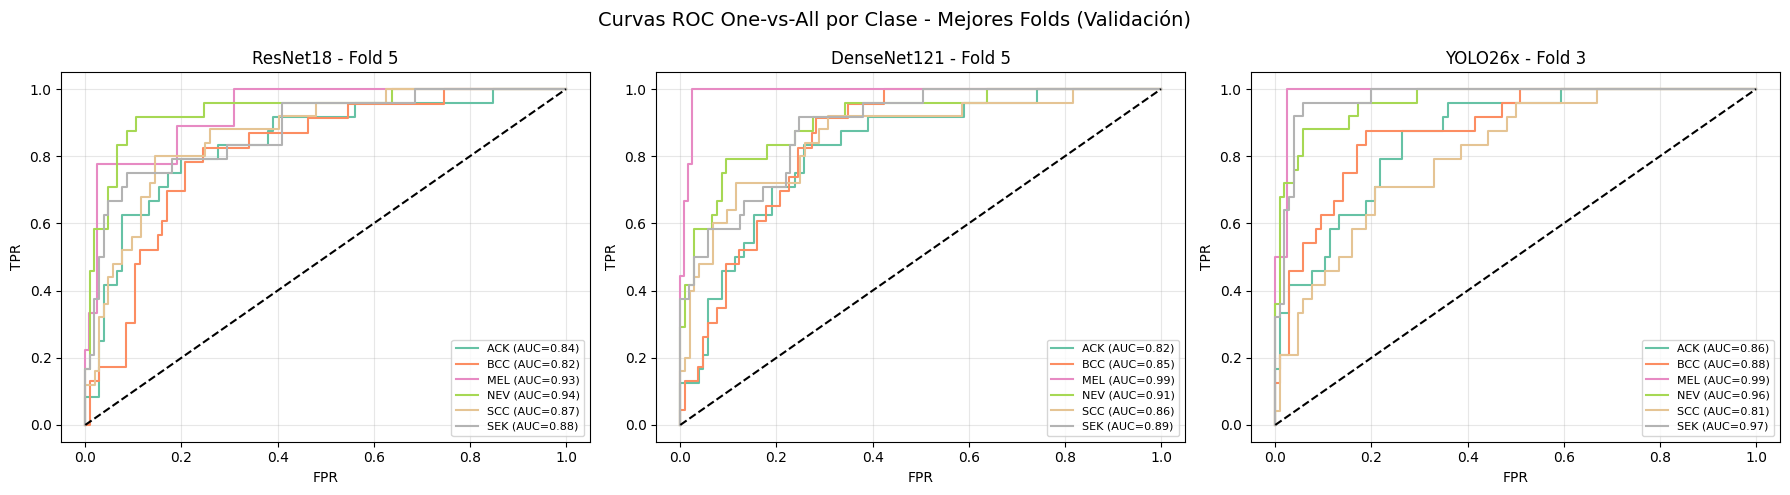


RESUMEN: MEJORES FOLDS POR MODELO (VALIDACIÓN)
     Modelo  Mejor_Fold  Mejor_AUC_Macro  F1_Macro
   ResNet18           5           0.8792    0.6312
DenseNet121           5           0.8871    0.6098
    YOLO26x           3           0.9131    0.6263

>>> Mejores folds guardados:
    MEJOR_FOLD_RESNET = 5
    MEJOR_FOLD_DENSENET = 5
    MEJOR_FOLD_YOLO = 3


In [16]:
# ============================================================
# COMPARATIVA AUC ROC ONE-VS-ALL - 5 FOLDS (VALIDACIÓN)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
import torch
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)

print("="*70)
print("COMPARATIVA AUC ROC ONE-VS-ALL - 5 FOLDS (VALIDACIÓN)")
print("="*70)

def calcular_auc_macro_ova(y_true, y_probs, num_classes):
    """Calcula el AUC macro promedio usando One-vs-All."""
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    aucs = []
    for i in range(num_classes):
        if len(np.unique(y_true_bin[:, i])) > 1:  # Necesita ambas clases
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            aucs.append(auc(fpr, tpr))
    return np.mean(aucs) if aucs else 0.0

# ============================================================
# 1. RESNET - AUC ROC One-vs-All de los 5 folds
# ============================================================

print("\n>>> Evaluando ResNet 5 folds en validación...")

resnet_aucs = []
resnet_f1s = []

for fold_idx in range(K_FOLDS):
    # Cargar modelo
    model, _ = crear_resnet18(num_classes, device)
    model.load_state_dict(torch.load(f"ResNet18_5Fold_fold{fold_idx+1}.pth", map_location=device))
    model.eval()
    
    # Obtener val loader del fold
    train_idx, val_idx = list(skf.split(range(len(targets)), targets))[fold_idx]
    fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
    val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    
    # Predicciones
    y_true, y_pred, y_probs = obtener_predicciones(model, val_loader, device)
    
    # AUC ROC macro (One-vs-All)
    auc_macro = calcular_auc_macro_ova(y_true, y_probs, num_classes)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    resnet_aucs.append(auc_macro)
    resnet_f1s.append(f1)
    print(f"  Fold {fold_idx+1}: AUC_macro={auc_macro:.4f}, F1_macro={f1:.4f}")

# ============================================================
# 2. DENSENET - AUC ROC One-vs-All de los 5 folds
# ============================================================

print("\n>>> Evaluando DenseNet 5 folds en validación...")

densenet_aucs = []
densenet_f1s = []

for fold_idx in range(K_FOLDS):
    model, _ = crear_densenet121(num_classes, device)
    model.load_state_dict(torch.load(f"DenseNet121_5Fold_fold{fold_idx+1}.pth", map_location=device))
    model.eval()
    
    train_idx, val_idx = list(skf.split(range(len(targets)), targets))[fold_idx]
    fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
    val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    
    y_true, y_pred, y_probs = obtener_predicciones(model, val_loader, device)
    
    auc_macro = calcular_auc_macro_ova(y_true, y_probs, num_classes)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    densenet_aucs.append(auc_macro)
    densenet_f1s.append(f1)
    print(f"  Fold {fold_idx+1}: AUC_macro={auc_macro:.4f}, F1_macro={f1:.4f}")

# ============================================================
# 3. YOLO - AUC ROC One-vs-All de los 5 folds
# ============================================================

print("\n>>> Evaluando YOLO 5 folds en validación...")

yolo_aucs = []
yolo_f1s = []

for fold_idx in range(K_FOLDS):
    model_yolo = YOLO(f"runs/classify/runs/YOLO26x_Fold{fold_idx+1}/weights/best.pt")
    
    # Carpeta de validación del fold
    val_path = os.path.join(FOLDS_DIR, f"fold_{fold_idx+1}", "val")
    y_true, y_pred, y_probs = obtener_predicciones_yolo(model_yolo, val_path, classes)
    
    auc_macro = calcular_auc_macro_ova(y_true, y_probs, num_classes)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    yolo_aucs.append(auc_macro)
    yolo_f1s.append(f1)
    print(f"  Fold {fold_idx+1}: AUC_macro={auc_macro:.4f}, F1_macro={f1:.4f}")
    
    del model_yolo
    gc.collect()
    torch.cuda.empty_cache()

# ============================================================
# 4. GRÁFICA COMPARATIVA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ResNet
ax = axes[0]
x = np.arange(1, K_FOLDS + 1)
bars = ax.bar(x - 0.2, resnet_aucs, 0.4, label='AUC Macro', color='steelblue')
bars2 = ax.bar(x + 0.2, resnet_f1s, 0.4, label='F1 Macro', color='seagreen')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title(f'ResNet18 - 5 Folds\nMejor: Fold {np.argmax(resnet_aucs)+1} (AUC={max(resnet_aucs):.3f})')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

# DenseNet
ax = axes[1]
bars = ax.bar(x - 0.2, densenet_aucs, 0.4, label='AUC Macro', color='steelblue')
bars2 = ax.bar(x + 0.2, densenet_f1s, 0.4, label='F1 Macro', color='seagreen')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title(f'DenseNet121 - 5 Folds\nMejor: Fold {np.argmax(densenet_aucs)+1} (AUC={max(densenet_aucs):.3f})')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

# YOLO
ax = axes[2]
bars = ax.bar(x - 0.2, yolo_aucs, 0.4, label='AUC Macro', color='steelblue')
bars2 = ax.bar(x + 0.2, yolo_f1s, 0.4, label='F1 Macro', color='seagreen')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title(f'YOLO26x - 5 Folds\nMejor: Fold {np.argmax(yolo_aucs)+1} (AUC={max(yolo_aucs):.3f})')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

plt.suptitle('AUC ROC Macro (One-vs-All) y F1 Macro por Fold (Validación)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 5. CURVAS ROC POR CLASE - MEJOR FOLD DE CADA MODELO
# ============================================================

print("\n" + "="*70)
print("CURVAS ROC POR CLASE - MEJORES FOLDS")
print("="*70)

best_fold_resnet = np.argmax(resnet_aucs)
best_fold_densenet = np.argmax(densenet_aucs)
best_fold_yolo = np.argmax(yolo_aucs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, num_classes))

# --- ResNet mejor fold ---
ax = axes[0]
model, _ = crear_resnet18(num_classes, device)
model.load_state_dict(torch.load(f"ResNet18_5Fold_fold{best_fold_resnet+1}.pth", map_location=device))
model.eval()

train_idx, val_idx = list(skf.split(range(len(targets)), targets))[best_fold_resnet]
fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
y_true, _, y_probs = obtener_predicciones(model, val_loader, device)

y_true_bin = label_binarize(y_true, classes=range(num_classes))
for i, class_name in enumerate(classes):
    if len(np.unique(y_true_bin[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], label=f'{class_name} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ResNet18 - Fold {best_fold_resnet+1}')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# --- DenseNet mejor fold ---
ax = axes[1]
model, _ = crear_densenet121(num_classes, device)
model.load_state_dict(torch.load(f"DenseNet121_5Fold_fold{best_fold_densenet+1}.pth", map_location=device))
model.eval()

train_idx, val_idx = list(skf.split(range(len(targets)), targets))[best_fold_densenet]
fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
y_true, _, y_probs = obtener_predicciones(model, val_loader, device)

y_true_bin = label_binarize(y_true, classes=range(num_classes))
for i, class_name in enumerate(classes):
    if len(np.unique(y_true_bin[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], label=f'{class_name} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'DenseNet121 - Fold {best_fold_densenet+1}')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# --- YOLO mejor fold ---
ax = axes[2]
model_yolo = YOLO(f"runs/classify/runs/YOLO26x_Fold{best_fold_yolo+1}/weights/best.pt")
val_path = os.path.join(FOLDS_DIR, f"fold_{best_fold_yolo+1}", "val")
y_true, _, y_probs = obtener_predicciones_yolo(model_yolo, val_path, classes)

y_true_bin = label_binarize(y_true, classes=range(num_classes))
for i, class_name in enumerate(classes):
    if len(np.unique(y_true_bin[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], label=f'{class_name} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'YOLO26x - Fold {best_fold_yolo+1}')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

del model_yolo
gc.collect()
torch.cuda.empty_cache()

plt.suptitle('Curvas ROC One-vs-All por Clase - Mejores Folds (Validación)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# TABLA RESUMEN
# ============================================================

import pandas as pd

print("\n" + "="*70)
print("RESUMEN: MEJORES FOLDS POR MODELO (VALIDACIÓN)")
print("="*70)

resumen = pd.DataFrame({
    'Modelo': ['ResNet18', 'DenseNet121', 'YOLO26x'],
    'Mejor_Fold': [np.argmax(resnet_aucs)+1, np.argmax(densenet_aucs)+1, np.argmax(yolo_aucs)+1],
    'Mejor_AUC_Macro': [max(resnet_aucs), max(densenet_aucs), max(yolo_aucs)],
    'F1_Macro': [resnet_f1s[np.argmax(resnet_aucs)], densenet_f1s[np.argmax(densenet_aucs)], yolo_f1s[np.argmax(yolo_aucs)]]
})
print(resumen.round(4).to_string(index=False))

# Guardar mejores folds para uso posterior
MEJOR_FOLD_RESNET = np.argmax(resnet_aucs) + 1
MEJOR_FOLD_DENSENET = np.argmax(densenet_aucs) + 1
MEJOR_FOLD_YOLO = np.argmax(yolo_aucs) + 1

print(f"\n>>> Mejores folds guardados:")
print(f"    MEJOR_FOLD_RESNET = {MEJOR_FOLD_RESNET}")
print(f"    MEJOR_FOLD_DENSENET = {MEJOR_FOLD_DENSENET}")
print(f"    MEJOR_FOLD_YOLO = {MEJOR_FOLD_YOLO}")

### Resultados - Comparación AUC-ROC

**Mejores Folds por Modelo (seleccionados por AUC):**

| Modelo | Mejor Fold | AUC-Macro | F1-Macro |
|--------|------------|-----------|----------|
| YOLO26x | Fold 3 | **0.9131** | 0.6263 |
| DenseNet121 | Fold 5 | 0.8871 | 0.6098 |
| ResNet18 | Fold 5 | 0.8792 | **0.6312** |

**Observaciones:**
- **YOLO lidera en AUC** (0.91) pero no en F1: tiene buenas probabilidades pero mal umbral
- **ResNet lidera en F1** (0.63) con AUC sólido (0.88): mejor calibrado
- Todos superan ampliamente el baseline aleatorio (AUC=0.5)

**Selección para Ensemble:**
- ResNet18: Fold 5
- DenseNet121: Fold 5  
- YOLO26x: Fold 3

## 8. Ensemble Final

✓ Modelos cargados
✓ Predicciones obtenidas: 153 muestras en test

RESULTADOS EN TEST
ResNet Fold5:     F1 = 0.5519  |  AUC Macro = 0.8551
DenseNet Fold5:   F1 = 0.5092  |  AUC Macro = 0.8412
YOLO Fold3:       F1 = 0.5527  |  AUC Macro = 0.8553
────────────────────────────────────────────────────────────
Ensemble (0.33/0.33/0.34): F1 = 0.6122  |  AUC Macro = 0.8718


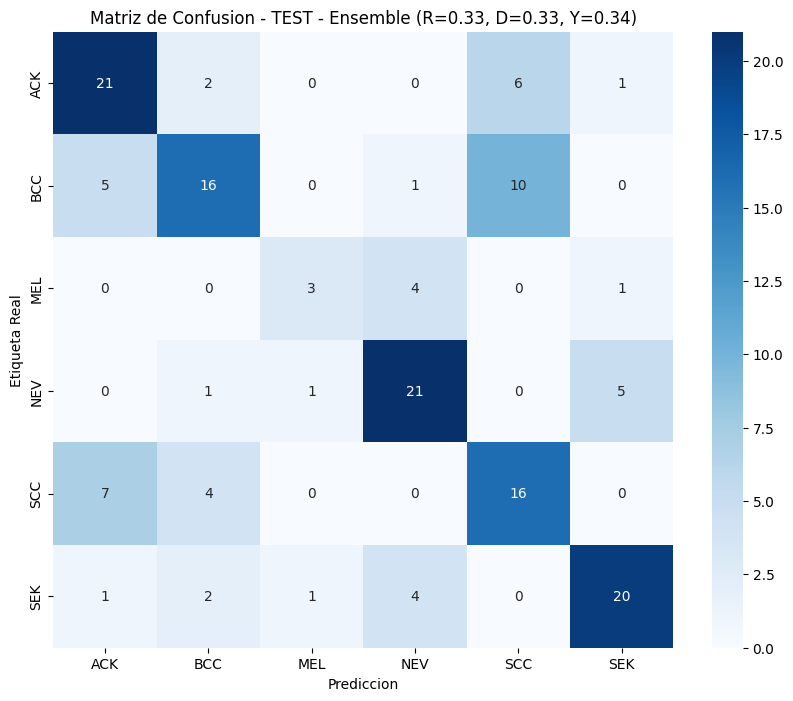


REPORTE: TEST - Ensemble (R=0.33, D=0.33, Y=0.34)
              precision    recall  f1-score   support

         ACK       0.62      0.70      0.66        30
         BCC       0.64      0.50      0.56        32
         MEL       0.60      0.38      0.46         8
         NEV       0.70      0.75      0.72        28
         SCC       0.50      0.59      0.54        27
         SEK       0.74      0.71      0.73        28

    accuracy                           0.63       153
   macro avg       0.63      0.61      0.61       153
weighted avg       0.64      0.63      0.63       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6340
  F1 Macro:           0.6122
  F1 Weighted:        0.6316
  Precision Macro:    0.6331
  Precision Weighted: 0.6382
  Recall Macro:       0.6053
  Recall Weighted:    0.6340
  Cohen's Kappa:      0.5512


{'f1_macro': 0.612162584995589,
 'f1_weighted': 0.6315574261583103,
 'accuracy': 0.6339869281045751,
 'precision_macro': 0.6330646332607116,
 'precision_weighted': 0.638236290885272,
 'recall_macro': 0.6053130511463846,
 'recall_weighted': 0.6339869281045751,
 'kappa': 0.5511551155115512}

In [20]:
# ============================================================
# ENSEMBLE MANUAL - EVALUACIÓN EN TEST
# ============================================================

import numpy as np
import torch
from ultralytics import YOLO
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)

# ============================================================
# 1. CARGAR LOS 3 MEJORES MODELOS
# ============================================================

# ResNet Fold 5
model_resnet, _ = crear_resnet18(num_classes, device)
model_resnet.load_state_dict(torch.load("ResNet18_5Fold_fold5.pth", map_location=device))
model_resnet.eval()

# DenseNet Fold 1
model_densenet, _ = crear_densenet121(num_classes, device)
model_densenet.load_state_dict(torch.load("DenseNet121_5Fold_fold5.pth", map_location=device))
model_densenet.eval()

# YOLO Fold 5
model_yolo = YOLO("runs/classify/runs/YOLO26x_Fold3/weights/best.pt")

print("✓ Modelos cargados")

# ============================================================
# 2. OBTENER PREDICCIONES EN TEST
# ============================================================

# ResNet - CORREGIDO: y_true es el primer valor retornado
y_true_test, _, probs_resnet = obtener_predicciones(model_resnet, test_loader, device)

# DenseNet
_, _, probs_densenet = obtener_predicciones(model_densenet, test_loader, device)

# YOLO
RUTA_TEST = os.path.abspath(os.path.join(RUTA_BASE, "test"))
_, _, probs_yolo = obtener_predicciones_yolo(model_yolo, RUTA_TEST, classes)

print(f"✓ Predicciones obtenidas: {len(y_true_test)} muestras en test")

# Convertir probs a predicciones
y_pred_resnet = np.argmax(probs_resnet, axis=1)
y_pred_densenet = np.argmax(probs_densenet, axis=1)
y_pred_yolo = np.argmax(probs_yolo, axis=1)

# ============================================================
# 3. ENSEMBLE CON PESOS MANUALES
# ============================================================

# --- AJUSTA ESTOS PESOS ---
w_resnet = 0.33
w_densenet = 0.33
w_yolo = 0.34
# --------------------------

# Ensemble
probs_ensemble = w_resnet * probs_resnet + w_densenet * probs_densenet + w_yolo * probs_yolo
preds_ensemble = np.argmax(probs_ensemble, axis=1)

# ============================================================
# 4. EVALUACIÓN
# ============================================================

# Métricas individuales - F1 Score
f1_r = f1_score(y_true_test, y_pred_resnet, average='macro')
f1_d = f1_score(y_true_test, y_pred_densenet, average='macro')
f1_y = f1_score(y_true_test, y_pred_yolo, average='macro')
f1_e = f1_score(y_true_test, preds_ensemble, average='macro')

# Métricas individuales - AUC Macro
auc_r = roc_auc_score(y_true_test, probs_resnet, multi_class='ovr', average='macro')
auc_d = roc_auc_score(y_true_test, probs_densenet, multi_class='ovr', average='macro')
auc_y = roc_auc_score(y_true_test, probs_yolo, multi_class='ovr', average='macro')
auc_e = roc_auc_score(y_true_test, probs_ensemble, multi_class='ovr', average='macro')

print(f"\n{'='*60}")
print(f"RESULTADOS EN TEST")
print(f"{'='*60}")
print(f"ResNet Fold5:     F1 = {f1_r:.4f}  |  AUC Macro = {auc_r:.4f}")
print(f"DenseNet Fold5:   F1 = {f1_d:.4f}  |  AUC Macro = {auc_d:.4f}")
print(f"YOLO Fold3:       F1 = {f1_y:.4f}  |  AUC Macro = {auc_y:.4f}")
print(f"{'─'*60}")
print(f"Ensemble ({w_resnet}/{w_densenet}/{w_yolo}): F1 = {f1_e:.4f}  |  AUC Macro = {auc_e:.4f}")
print(f"{'='*60}")

# Reporte completo del ensemble
mostrar_reporte_completo(
    y_true_test, preds_ensemble, classes,
    f"TEST - Ensemble (R={w_resnet}, D={w_densenet}, Y={w_yolo})"
)

### Selección del Ensemble

Probamos dos configuraciones:
- **Por F1**: ResNet(5) + DenseNet(1) + YOLO(5)
- **Por AUC**: ResNet(5) + DenseNet(5) + YOLO(3)

| Configuración | F1-Test | AUC-Test | MEL Recall |
|---------------|---------|----------|------------|
| Por F1 (5-1-5) | 0.6008 | 0.8826 | 38% |
| **Por AUC (5-5-3)** | **0.6122** | 0.8718 | 38% |

**Seleccionamos el ensemble por AUC** porque mejora F1 en +1.9% sin sacrificar MEL recall.

### Resultados en Test

**Modelos Individuales vs Ensemble:**

| Modelo | F1-Test | AUC-Test |
|--------|---------|----------|
| ResNet Fold 5 | 0.5519 | 0.8551 |
| DenseNet Fold 5 | 0.5092 | 0.8412 |
| YOLO Fold 3 | 0.5527 | 0.8553 |
| **Ensemble** | **0.6122** | **0.8718** |

El ensemble mejora +10.8% en F1 sobre el mejor modelo individual.

**Performance por clase en test:**

| Clase | Recall |
|-------|--------|
| ACK | 70% |
| BCC | 50% |
| **MEL** | **38%** ❌ |
| NEV | 75% |
| SCC | 59% |
| SEK | 71% |

**Problema crítico:** MEL Recall cae de 70% (validación) a 38% (test). Solo detectamos 3 de 8 melanomas.

**Causa probable:** El test tiene solo 8 melanomas. Fallar 5 representa una caída brutal. Con tan pocos casos, la métrica es muy inestable.

✓ Modelos cargados
✓ Predicciones en test: 153 muestras

COMPARATIVA MODELOS INDIVIDUALES - VALIDACIÓN vs TEST
             Modelo  F1_Val  F1_Test  Accuracy_Test  Kappa_Test  Diff (Test-Val)
   ResNet18 (Fold5)  0.6312   0.5519         0.5882      0.4971          -0.0793
DenseNet121 (Fold5)  0.6098   0.5092         0.5294      0.4267          -0.1006
    YOLO26x (Fold3)  0.6263   0.5527         0.5686      0.4718          -0.0736

REPORTES DETALLADOS EN TEST


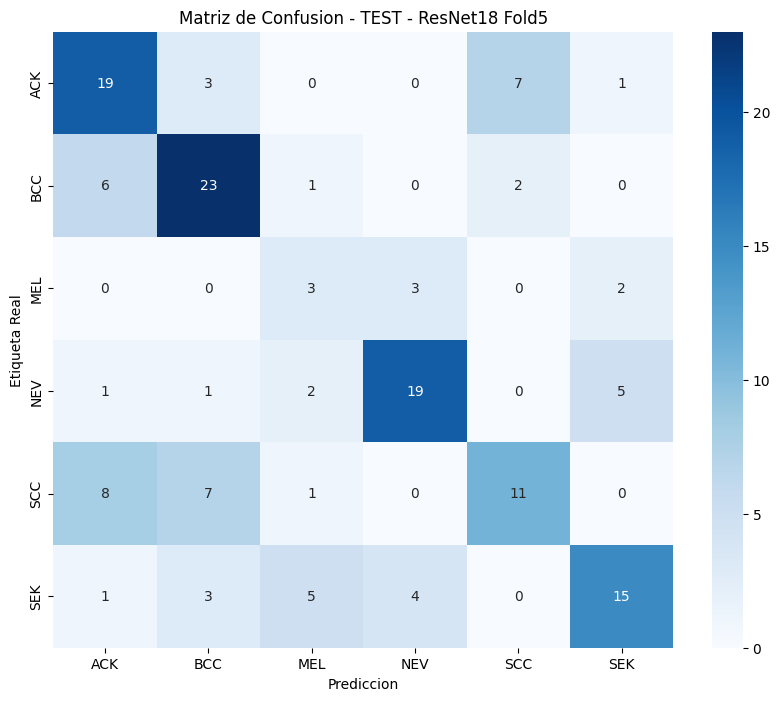


REPORTE: TEST - ResNet18 Fold5
              precision    recall  f1-score   support

         ACK       0.54      0.63      0.58        30
         BCC       0.62      0.72      0.67        32
         MEL       0.25      0.38      0.30         8
         NEV       0.73      0.68      0.70        28
         SCC       0.55      0.41      0.47        27
         SEK       0.65      0.54      0.59        28

    accuracy                           0.59       153
   macro avg       0.56      0.56      0.55       153
weighted avg       0.60      0.59      0.59       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5882
  F1 Macro:           0.5519
  F1 Weighted:        0.5888
  Precision Macro:    0.5579
  Precision Weighted: 0.5997
  Recall Macro:       0.5581
  Recall Weighted:    0.5882
  Cohen's Kappa:      0.4971


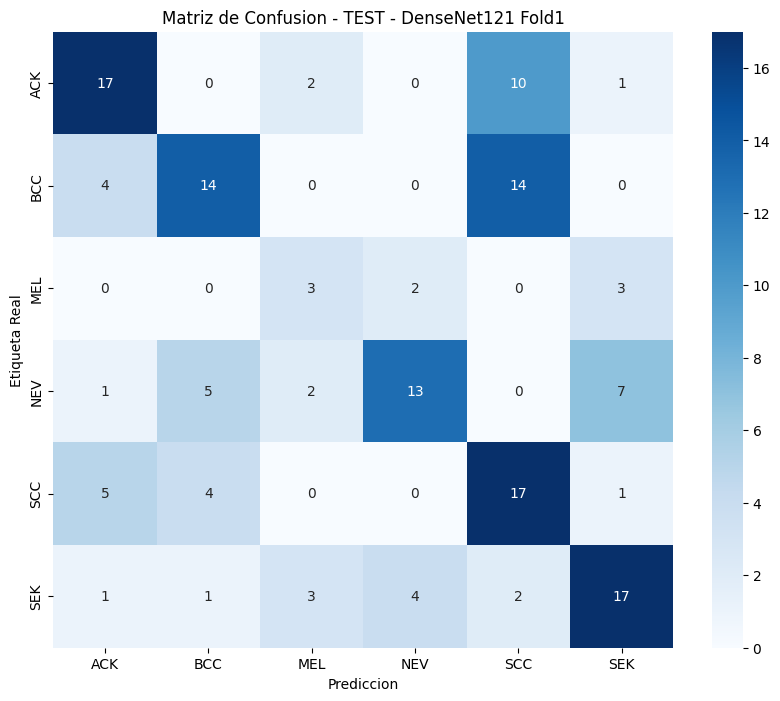


REPORTE: TEST - DenseNet121 Fold1
              precision    recall  f1-score   support

         ACK       0.61      0.57      0.59        30
         BCC       0.58      0.44      0.50        32
         MEL       0.30      0.38      0.33         8
         NEV       0.68      0.46      0.55        28
         SCC       0.40      0.63      0.49        27
         SEK       0.59      0.61      0.60        28

    accuracy                           0.53       153
   macro avg       0.53      0.51      0.51       153
weighted avg       0.56      0.53      0.53       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5294
  F1 Macro:           0.5092
  F1 Weighted:        0.5331
  Precision Macro:    0.5260
  Precision Weighted: 0.5590
  Recall Macro:       0.5134
  Recall Weighted:    0.5294
  Cohen's Kappa:      0.4267


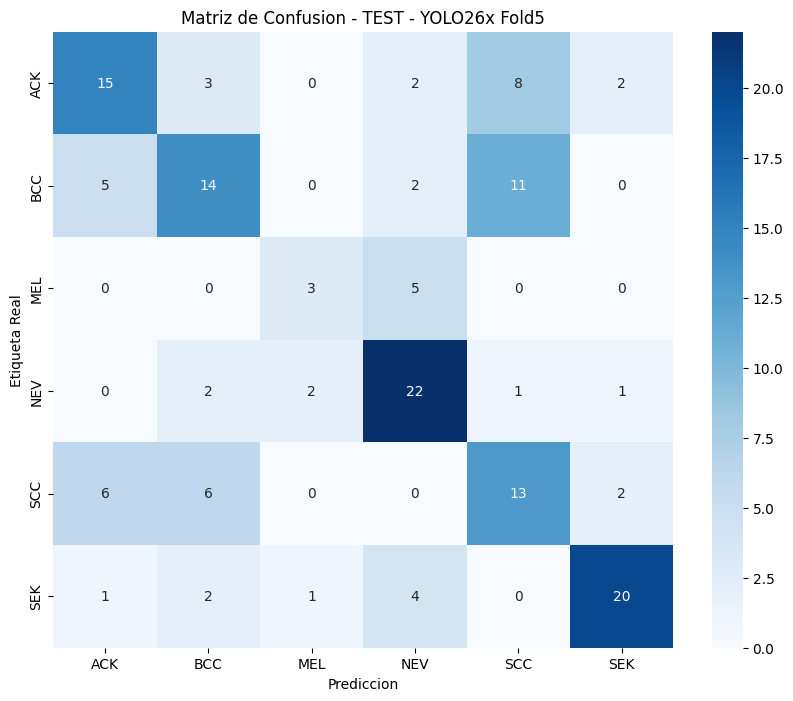


REPORTE: TEST - YOLO26x Fold5
              precision    recall  f1-score   support

         ACK       0.56      0.50      0.53        30
         BCC       0.52      0.44      0.47        32
         MEL       0.50      0.38      0.43         8
         NEV       0.63      0.79      0.70        28
         SCC       0.39      0.48      0.43        27
         SEK       0.80      0.71      0.75        28

    accuracy                           0.57       153
   macro avg       0.57      0.55      0.55       153
weighted avg       0.57      0.57      0.57       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5686
  F1 Macro:           0.5527
  F1 Weighted:        0.5673
  Precision Macro:    0.5661
  Precision Weighted: 0.5745
  Recall Macro:       0.5490
  Recall Weighted:    0.5686
  Cohen's Kappa:      0.4718


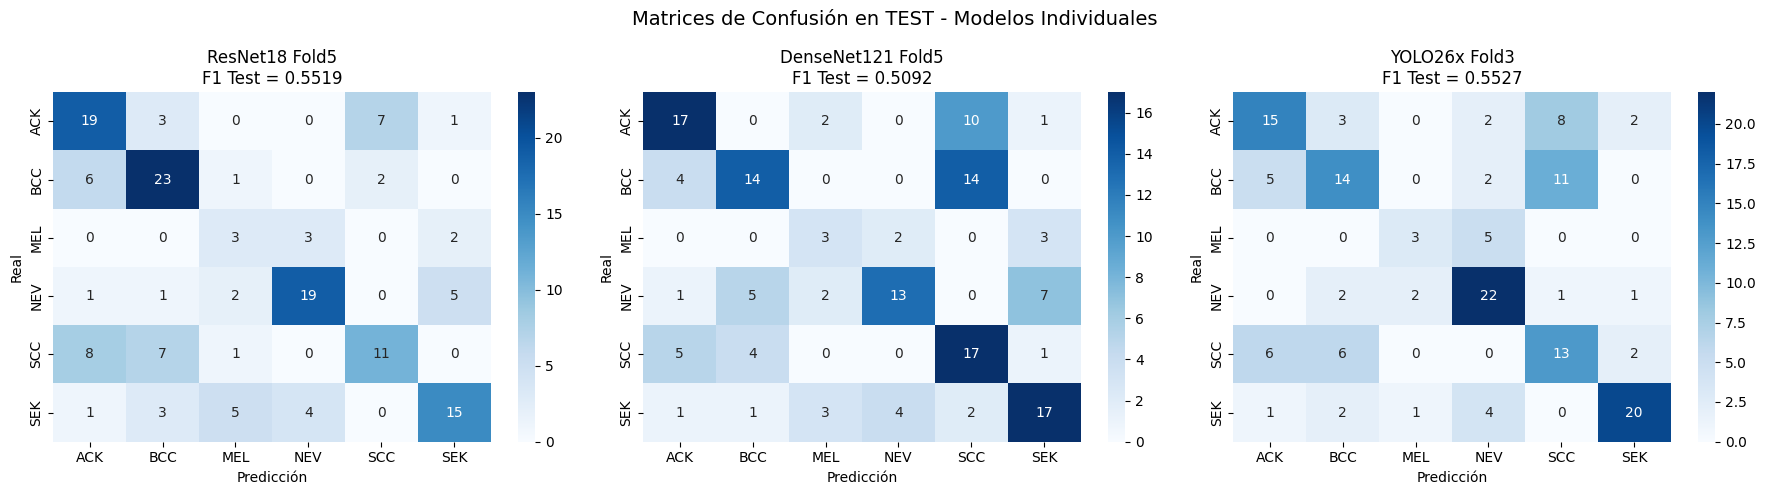


✓ Evaluación individual completada


In [24]:
# ============================================================
# EVALUACIÓN INDIVIDUAL EN TEST - TODOS LOS MODELOS
# ============================================================

import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)

# ============================================================
# 1. CARGAR MODELOS
# ============================================================

# ResNet Fold 5
model_resnet, _ = crear_resnet18(num_classes, device)
model_resnet.load_state_dict(torch.load("ResNet18_5Fold_fold5.pth", map_location=device))
model_resnet.eval()

# DenseNet Fold 1
model_densenet, _ = crear_densenet121(num_classes, device)
model_densenet.load_state_dict(torch.load("DenseNet121_5Fold_fold5.pth", map_location=device))
model_densenet.eval()

# YOLO Fold 5
model_yolo = YOLO("runs/classify/runs/YOLO26x_Fold3/weights/best.pt")

print("✓ Modelos cargados")

# ============================================================
# 2. PREDICCIONES EN TEST
# ============================================================

# ResNet
y_true_test, y_pred_resnet, probs_resnet = obtener_predicciones(model_resnet, test_loader, device)

# DenseNet
_, y_pred_densenet, probs_densenet = obtener_predicciones(model_densenet, test_loader, device)

# YOLO
RUTA_TEST = os.path.abspath(os.path.join(RUTA_BASE, "test"))
_, y_pred_yolo, probs_yolo = obtener_predicciones_yolo(model_yolo, RUTA_TEST, classes)

print(f"✓ Predicciones en test: {len(y_true_test)} muestras")

# ============================================================
# 3. CALCULAR MÉTRICAS
# ============================================================

def get_metrics(y_true, y_pred):
    return {
        'F1_macro': f1_score(y_true, y_pred, average='macro'),
        'F1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred)
    }

metricas_resnet = get_metrics(y_true_test, y_pred_resnet)
metricas_densenet = get_metrics(y_true_test, y_pred_densenet)
metricas_yolo = get_metrics(y_true_test, y_pred_yolo)

# ============================================================
# 4. TABLA COMPARATIVA
# ============================================================

# F1 de validación (conocidos del entrenamiento previo)
# ResNet Fold 5, DenseNet Fold 5, YOLO Fold 3
f1_val_resnet = 0.6312
f1_val_densenet = 0.6098
f1_val_yolo = 0.6263

df_comparativa = pd.DataFrame({
    'Modelo': ['ResNet18 (Fold5)', 'DenseNet121 (Fold5)', 'YOLO26x (Fold3)'],
    'F1_Val': [f1_val_resnet, f1_val_densenet, f1_val_yolo],
    'F1_Test': [metricas_resnet['F1_macro'], metricas_densenet['F1_macro'], metricas_yolo['F1_macro']],
    'Accuracy_Test': [metricas_resnet['Accuracy'], metricas_densenet['Accuracy'], metricas_yolo['Accuracy']],
    'Kappa_Test': [metricas_resnet['Kappa'], metricas_densenet['Kappa'], metricas_yolo['Kappa']]
})

df_comparativa['Diff (Test-Val)'] = df_comparativa['F1_Test'] - df_comparativa['F1_Val']

print(f"\n{'='*80}")
print("COMPARATIVA MODELOS INDIVIDUALES - VALIDACIÓN vs TEST")
print(f"{'='*80}")
print(df_comparativa.round(4).to_string(index=False))

# ============================================================
# 5. REPORTES DETALLADOS
# ============================================================

print(f"\n{'='*80}")
print("REPORTES DETALLADOS EN TEST")
print(f"{'='*80}")

mostrar_reporte_completo(y_true_test, y_pred_resnet, classes, "TEST - ResNet18 Fold5")
mostrar_reporte_completo(y_true_test, y_pred_densenet, classes, "TEST - DenseNet121 Fold1")
mostrar_reporte_completo(y_true_test, y_pred_yolo, classes, "TEST - YOLO26x Fold5")

# ============================================================
# 6. MATRICES DE CONFUSIÓN COMPARATIVAS
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [
    ('ResNet18 Fold5', y_pred_resnet),
    ('DenseNet121 Fold5', y_pred_densenet),
    ('YOLO26x Fold3', y_pred_yolo)
]):
    cm = confusion_matrix(y_true_test, y_pred)
    f1 = f1_score(y_true_test, y_pred, average='macro')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'{name}\nF1 Test = {f1:.4f}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.suptitle('Matrices de Confusión en TEST - Modelos Individuales', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n✓ Evaluación individual completada")

## 9. Conclusiones Finales

### Resultados

| Modelo | F1-Val | F1-Test | Drop | MEL Recall |
|--------|--------|---------|------|------------|
| ResNet18 | 0.6312 | 0.5519 | -12.6% | 38% |
| DenseNet121 | 0.6098 | 0.5092 | -16.5% | 38% |
| YOLO26x | 0.6263 | 0.5527 | -11.8% | 38% |
| **Ensemble** | ~0.59 | **0.6122** | +3.7% | **38%** |

### Lo que aprendimos

**1. El ensemble funciona:** Mejora +10.8% sobre modelos individuales. Combina las fortalezas de cada arquitectura.

**2. Todos los modelos sufren drop de validación a test:** Entre -12% y -17%. Hay cierto overfitting al conjunto de validación.

**3. El problema de MEL:** Todos detectan solo 3/8 melanomas en test. En validación detectaban ~70%. El test tiene muy pocos casos de MEL (8) para evaluar de forma robusta.

**4. Clases bien detectadas:** NEV (75%), SEK (71%), ACK (70%)

### Limitaciones

- **Recall de MEL inaceptable para uso clínico**: 38% = 5 melanomas no detectados
- **Dataset insuficiente**: Solo 52 MEL totales (44 train + 8 test)
- **Confusión grave MEL→NEV**: Melanomas clasificados como lunares benignos

### Recomendaciones

1. **No desplegar sin ajustes**: El recall de MEL es demasiado bajo
2. **Recolectar más datos de MEL**: Mínimo 200-300 casos
3. **Ajustar umbrales**: Reducir threshold para MEL (priorizar sensibilidad)
4. **Uso como screening**: Sistema de segunda opinión donde casos sospechosos van a especialista

El proyecto demuestra una metodología sólida, pero el dataset es insuficiente para aplicación clínica segura.